In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from lazypredict.Supervised import LazyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from dotenv import load_dotenv

In [2]:
load_dotenv()
input_data_path = "/home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv"

In [3]:
df = pd.read_csv(input_data_path)

In [4]:
df

,Unnamed: 0,game_id,season,game_date,game_stadium,home_team,away_team,home_coach,away_coach,total_home_score,...,prev_home_avg_yards_gained,prev_away_avg_yards_gained,prev_home_team_glicko_rating,prev_away_team_glicko_rating,prev_home_team_rd,prev_away_team_rd,prev_home_team_vol,prev_away_team_vol,h2h_home_win_ratio,h2h_away_win_ratio
0,0,1999_01_ARI_PHI,1999,1999-09-12,Veterans Stadium,PHI,ARI,Andy Reid,Vince Tobin,24.00,...,0.00,1.00,1513.56,1514.76,68.08,68.05,0.06,0.06,0.00,0.00
1,1,1999_01_SF_JAX,1999,1999-09-12,Alltel Stadium,JAX,SF,Tom Coughlin,Steve Mariucci,41.00,...,0.00,1.00,1513.56,1514.76,68.08,68.05,0.06,0.06,0.00,0.00
2,2,1999_01_PIT_CLE,1999,1999-09-12,Cleveland Browns Stadium,CLE,PIT,Chris Palmer,Bill Cowher,0.00,...,0.00,1.00,1513.56,1514.76,68.08,68.05,0.06,0.06,0.00,0.00
3,3,1999_01_OAK_GB,1999,1999-09-12,Lambeau Field,GB,LV,Ray Rhodes,Jon Gruden,28.00,...,0.00,1.00,1513.56,1514.76,68.08,68.05,0.06,0.06,0.00,0.00
4,4,1999_01_NYG_TB,1999,1999-09-12,Raymond James Stadium,TB,NYG,Tony Dungy,Jim Fassel,13.00,...,0.00,1.00,1513.56,1514.76,68.08,68.05,0.06,0.06,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7458,7458,2025_19_HOU_PIT,2025,2026-01-12,Acrisure Stadium,PIT,HOU,Mike Tomlin,DeMeco Ryans,6.00,...,0.00,0.00,1563.21,1573.10,61.34,61.87,0.06,0.06,0.60,0.40
7459,7459,2025_20_BUF_DEN,2025,2026-01-17,Empower Field at Mile High,DEN,BUF,Sean Payton,Sean McDermott,30.00,...,0.00,1.00,1588.42,1694.25,61.86,65.06,0.06,0.06,0.20,0.80
7460,7460,2025_20_SF_SEA,2025,2026-01-17,Lumen Field,SEA,SF,Mike Macdonald,Kyle Shanahan,41.00,...,1.00,1.00,1615.94,1583.23,61.78,61.98,0.06,0.06,0.40,0.60
7461,7461,2025_20_LA_CHI,2025,2026-01-18,Soldier Field,CHI,LA,Ben Johnson,Sean McVay,17.00,...,0.00,1.00,1490.58,1631.40,62.15,62.20,0.06,0.06,0.40,0.60


In [5]:
df.columns.tolist()

['Unnamed: 0',
 'game_id',
 'season',
 'game_date',
 'game_stadium',
 'home_team',
 'away_team',
 'home_coach',
 'away_coach',
 'total_home_score',
 'total_away_score',
 'total_home_epa',
 'total_away_epa',
 'total_home_rush_epa',
 'total_away_rush_epa',
 'total_home_pass_epa',
 'total_away_pass_epa',
 'home_first_down_rush',
 'home_first_down_pass',
 'home_third_down_converted',
 'home_fourth_down_converted',
 'home_interception',
 'home_fumble_lost',
 'home_fumble_forced',
 'home_rush_attempt',
 'home_pass_attempt',
 'home_pass_touchdown',
 'home_qb_dropback',
 'home_rush_touchdown',
 'home_tackled_for_loss',
 'home_qb_hit',
 'home_punt_attempt',
 'home_kickoff_attempt',
 'home_kickoff_inside_twenty',
 'home_penalty_yards',
 'home_rushing_yards',
 'home_passing_yards',
 'home_receiving_yards',
 'home_yards_gained',
 'home_sack',
 'away_first_down_rush',
 'away_first_down_pass',
 'away_third_down_converted',
 'away_fourth_down_converted',
 'away_interception',
 'away_fumble_lost',
 'a

## Encoding

In [6]:
teams = []
coach = []
for i in df[["home_team", "away_team", "home_coach", "away_coach"]].itertuples():
    if i.home_team not in teams:
        teams.append(i.home_team)
    
    if i.away_team not in teams:
        teams.append(i.away_team)
    
    if i.home_coach not in coach:
        coach.append(i.home_coach)

    if i.away_coach not in coach:
        coach.append(i.away_coach)


In [7]:
team_le = LabelEncoder()
coach_le = LabelEncoder()
ground_le = LabelEncoder()

In [8]:
team_le.fit(teams)
coach_le.fit(coach)
ground_le.fit(df["game_stadium"])


LabelEncoder()

In [9]:
df["home_team"] = team_le.transform(df["home_team"])
df["away_team"] = team_le.transform(df["away_team"])
df["home_coach"] = coach_le.transform(df["home_coach"])
df["away_coach"] = coach_le.transform(df["away_coach"])
df["game_stadium"] = ground_le.transform(df["game_stadium"])

In [10]:
df.columns.tolist()

['Unnamed: 0',
 'game_id',
 'season',
 'game_date',
 'game_stadium',
 'home_team',
 'away_team',
 'home_coach',
 'away_coach',
 'total_home_score',
 'total_away_score',
 'total_home_epa',
 'total_away_epa',
 'total_home_rush_epa',
 'total_away_rush_epa',
 'total_home_pass_epa',
 'total_away_pass_epa',
 'home_first_down_rush',
 'home_first_down_pass',
 'home_third_down_converted',
 'home_fourth_down_converted',
 'home_interception',
 'home_fumble_lost',
 'home_fumble_forced',
 'home_rush_attempt',
 'home_pass_attempt',
 'home_pass_touchdown',
 'home_qb_dropback',
 'home_rush_touchdown',
 'home_tackled_for_loss',
 'home_qb_hit',
 'home_punt_attempt',
 'home_kickoff_attempt',
 'home_kickoff_inside_twenty',
 'home_penalty_yards',
 'home_rushing_yards',
 'home_passing_yards',
 'home_receiving_yards',
 'home_yards_gained',
 'home_sack',
 'away_first_down_rush',
 'away_first_down_pass',
 'away_third_down_converted',
 'away_fourth_down_converted',
 'away_interception',
 'away_fumble_lost',
 'a

In [11]:
import numpy as np

In [12]:
remove_list = ['Unnamed: 0',
"season",
'game_id',
 'total_home_score',
 'total_away_score',
 'total_home_epa',
 'total_away_epa',
 'total_home_rush_epa',
 'total_away_rush_epa',
 'total_home_pass_epa',
 'total_away_pass_epa',
 'home_first_down_rush',
 'home_first_down_pass',
 'home_third_down_converted',
 'home_fourth_down_converted',
 'home_interception',
 'home_fumble_lost',
 'home_fumble_forced',
 'home_rush_attempt',
 'home_pass_attempt',
 'home_pass_touchdown',
 'home_qb_dropback',
 'home_rush_touchdown',
 'home_tackled_for_loss',
 'home_qb_hit',
 'home_punt_attempt',
 'home_kickoff_attempt',
 'home_kickoff_inside_twenty',
 'home_penalty_yards',
 'home_rushing_yards',
 'home_passing_yards',
 'home_receiving_yards',
 'home_yards_gained',
 'home_sack',
 'away_first_down_rush',
 'away_first_down_pass',
 'away_third_down_converted',
 'away_fourth_down_converted',
 'away_interception',
 'away_fumble_lost',
 'away_fumble_forced',
 'away_rush_attempt',
 'away_pass_attempt',
 'away_pass_touchdown',
 'away_qb_dropback',
 'away_rush_touchdown',
 'away_tackled_for_loss',
 'away_qb_hit',
 'away_punt_attempt',
 'away_kickoff_attempt',
 'away_kickoff_inside_twenty',
 'away_penalty_yards',
 'away_rushing_yards',
 'away_passing_yards',
 'away_receiving_yards',
 'away_yards_gained',
 'away_sack',
 'home_return_yards_positive',
 'away_return_yards_positive',
 'home_return_yards_negative',
 'away_return_yards_negative',
 'home_yards_after_catch_positive',
 'away_yards_after_catch_positive',
 'home_yards_after_catch_negative',
 'away_yards_after_catch_negative', "match_result", 
"home_team_glicko_rating",
"away_team_glicko_rating",
"home_team_rd",
"away_team_rd",
"home_team_vol",
"away_team_vol","game_date",
"df_row",
"home_pf",
"home_pa",
"away_pf",
"away_pa",
 'home_defense',
 'away_defense',
 'home_offense',
 'away_offense',
 'home_net_rating',
 'away_net_rating',
  'home_pct',
 'away_pct',
 'home_team_avg_score',
 'away_team_avg_score',
 'home_avg_passing_yards',
 'away_avg_passing_yards',
 'home_avg_receiving_yards',
 'away_avg_receiving_yards',
 'home_avg_rushing_yards',
 'away_avg_rushing_yards',
 'home_avg_yards_gained',
 'away_avg_yards_gained',
  'league_avg_score_before',
 'home_team_peformance',
 'away_team_peformance',
 'league_avg_passing_yards_before',
 'league_avg_receiving_yards_before',
 'league_avg_rushing_yards_before',
 'league_avg_yards_gained_before',
]



X = df.drop(columns= remove_list)
y = df["match_result"]

In [13]:
X.columns.tolist()

['game_stadium',
 'home_team',
 'away_team',
 'home_coach',
 'away_coach',
 'last_5_total_home_score',
 'last_5_total_away_score',
 'last_5_total_home_epa',
 'last_5_total_away_epa',
 'last_5_total_home_rush_epa',
 'last_5_total_away_rush_epa',
 'last_5_total_home_pass_epa',
 'last_5_total_away_pass_epa',
 'last_5_home_first_down_rush',
 'last_5_away_first_down_rush',
 'last_5_home_first_down_pass',
 'last_5_away_first_down_pass',
 'last_5_home_third_down_converted',
 'last_5_away_third_down_converted',
 'last_5_home_fourth_down_converted',
 'last_5_away_fourth_down_converted',
 'last_5_home_interception',
 'last_5_away_interception',
 'last_5_home_fumble_lost',
 'last_5_away_fumble_lost',
 'last_5_home_fumble_forced',
 'last_5_away_fumble_forced',
 'last_5_home_rush_attempt',
 'last_5_away_rush_attempt',
 'last_5_home_pass_attempt',
 'last_5_away_pass_attempt',
 'last_5_home_pass_touchdown',
 'last_5_away_pass_touchdown',
 'last_5_home_qb_dropback',
 'last_5_away_qb_dropback',
 'last_

In [18]:
# # Split data: test is strictly 2025, all other seasons are train
X_test = X[df['season'] == 2025]
y_test = y[df['season'] == 2025]
X_train = X[df['season'] != 2025]
y_train = y[df['season'] != 2025]


In [19]:
y_train.value_counts()

1.00    3775
0.00    2938
Name: match_result, dtype: int64

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from imblearn.over_sampling import SMOTEN

smote = SMOTEN(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

In [22]:
y_resampled.value_counts()

0.00    3775
1.00    3775
Name: match_result, dtype: int64

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Define the best parameters found by Optuna
# best_params = {
#     'n_estimators': 800,
#     'max_depth': 17,
#     'min_samples_split': 10,
#     'min_samples_leaf': 2,
#     'max_features': 'sqrt',
#     'class_weight': 'balanced_subsample',
#     'bootstrap': False,
#     'random_state': 42,
#     'n_jobs': -1
# }

best_params = {
    'n_estimators': 334, 
    'max_depth': 21, 
    'min_samples_split': 3, 
    'min_samples_leaf': 1, 
    'max_features': 'sqrt', 
    'bootstrap': False, 
    'class_weight': 'balanced'}

# Train the RandomForestClassifier on the resampled, scaled train set
rf_best = RandomForestClassifier(**best_params)
rf_best.fit(X_resampled, y_resampled)


,n_estimators,334
,criterion,'gini'
,max_depth,21
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [24]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict on the scaled test set
y_pred = rf_best.predict(X_test_scaled)
y_proba = rf_best.predict_proba(X_test_scaled)[:, 1]

# Generate classification report
rf_class_report = classification_report(y_test, y_pred, digits=3)
print("Random Forest Classification Report:\n", rf_class_report)

# Compute ROC AUC score
rf_roc_auc = roc_auc_score(y_test, y_proba)
print(f"Random Forest ROC AUC Score: {rf_roc_auc:.4f}")


Random Forest Classification Report:
               precision    recall  f1-score   support

         0.0      0.594     0.512     0.550       123
         1.0      0.623     0.697     0.658       142

    accuracy                          0.611       265
   macro avg      0.608     0.605     0.604       265
weighted avg      0.610     0.611     0.608       265

Random Forest ROC AUC Score: 0.6870


In [25]:

# ----------------------
# Initialize LazyClassifier
# ----------------------
clf = LazyClassifier(
    ignore_warnings=True,
    predictions=True,
    random_state=42
)

# ----------------------
# Fit and evaluate
# ----------------------
models, predictions = clf.fit(X_resampled, X_test_scaled, y_resampled, y_test)

# ----------------------
# View results
# ----------------------
print(models)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 3775, number of negative: 3775
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005694 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25706
[LightGBM] [Info] Number of data points in the train set: 7550, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
SVC                                0.66               0.65     0.65      0.65   
NuSVC                              0.65               0.65     0.65      0.65   
AdaBoostClassifier                 0.65               0.64     0.64      0.64   
BaggingClassifier                  0.64               0.64     0.64      0.64   
ExtraTreesClassifier               0.64               0.64     0.64      0.6

In [26]:
cat_model = CatBoostClassifier(
    depth=8,
    learning_rate=0.07019386624800321,
    l2_leaf_reg=2.472174406464648,
    bagging_temperature=0.6271459737483357,
    border_count=109,
    iterations=500,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=1,
    boosting_type="Ordered"
)

cat_model.fit(
    X_resampled, y_resampled, 
    eval_set=(X_test_scaled, y_test), 
    early_stopping_rounds=50
)

0:	learn: 0.6912607	test: 0.6907895	best: 0.6907895 (0)	total: 174ms	remaining: 1m 26s
1:	learn: 0.7038702	test: 0.6881029	best: 0.6907895 (0)	total: 298ms	remaining: 1m 14s
2:	learn: 0.7137998	test: 0.6853583	best: 0.6907895 (0)	total: 446ms	remaining: 1m 13s
3:	learn: 0.7152736	test: 0.6896552	best: 0.6907895 (0)	total: 572ms	remaining: 1m 10s
4:	learn: 0.7157101	test: 0.7047619	best: 0.7047619 (4)	total: 710ms	remaining: 1m 10s
5:	learn: 0.7149277	test: 0.6981132	best: 0.7047619 (4)	total: 840ms	remaining: 1m 9s
6:	learn: 0.7165230	test: 0.7147335	best: 0.7147335 (6)	total: 965ms	remaining: 1m 7s
7:	learn: 0.7163129	test: 0.7025316	best: 0.7147335 (6)	total: 1.1s	remaining: 1m 7s
8:	learn: 0.7170223	test: 0.7006369	best: 0.7147335 (6)	total: 1.22s	remaining: 1m 6s
9:	learn: 0.7133960	test: 0.7047619	best: 0.7147335 (6)	total: 1.35s	remaining: 1m 6s
10:	learn: 0.7145295	test: 0.7021944	best: 0.7147335 (6)	total: 1.47s	remaining: 1m 5s
11:	learn: 0.7142857	test: 0.7028754	best: 0.7147

In [27]:
from catboost import CatBoostClassifier

# Train the CatBoostClassifier with best parameters
cat_model_best = CatBoostClassifier(
    learning_rate=0.05,
    l2_leaf_reg=1,
    iterations=1000,
    depth=10,
    border_count=128,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=1,
    boosting_type="Ordered"
)

cat_model_best.fit(
    X_resampled, y_resampled, 
    eval_set=(X_test_scaled, y_test), 
    early_stopping_rounds=50
)

0:	learn: 0.6934647	test: 0.6758621	best: 0.6758621 (0)	total: 554ms	remaining: 9m 13s
1:	learn: 0.7199020	test: 0.6645963	best: 0.6758621 (0)	total: 1.12s	remaining: 9m 18s
2:	learn: 0.7226788	test: 0.6812500	best: 0.6812500 (2)	total: 1.64s	remaining: 9m 4s
3:	learn: 0.7212144	test: 0.6900958	best: 0.6900958 (3)	total: 2.17s	remaining: 9m
4:	learn: 0.7224475	test: 0.7044025	best: 0.7044025 (4)	total: 2.7s	remaining: 8m 57s
5:	learn: 0.7245172	test: 0.6772152	best: 0.7044025 (4)	total: 3.28s	remaining: 9m 3s
6:	learn: 0.7226420	test: 0.6857143	best: 0.7044025 (4)	total: 3.8s	remaining: 8m 58s
7:	learn: 0.7267202	test: 0.7044025	best: 0.7044025 (4)	total: 4.33s	remaining: 8m 57s
8:	learn: 0.7240039	test: 0.6962025	best: 0.7044025 (4)	total: 4.87s	remaining: 8m 56s
9:	learn: 0.7232490	test: 0.6940063	best: 0.7044025 (4)	total: 5.37s	remaining: 8m 51s
10:	learn: 0.7230321	test: 0.6794872	best: 0.7044025 (4)	total: 5.85s	remaining: 8m 46s
11:	learn: 0.7234610	test: 0.7000000	best: 0.70440

In [23]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict class labels and probabilities on the test set
y_pred_best = cat_model_best.predict(X_test_scaled)
y_proba_best = cat_model_best.predict_proba(X_test_scaled)[:, 1]

# Generate and display the classification report
cat_best_report = classification_report(y_test, y_pred_best, digits=4)
print("CatBoost Best Model Classification Report:\n", cat_best_report)

# Compute and print ROC AUC score
cat_best_roc_auc = roc_auc_score(y_test, y_proba_best)

print(f"CatBoost Best Model ROC AUC: {cat_best_roc_auc:.4f}")


CatBoost Best Model Classification Report:
               precision    recall  f1-score   support

         0.0     0.6635    0.5610    0.6079       123
         1.0     0.6646    0.7535    0.7063       142

    accuracy                         0.6642       265
   macro avg     0.6640    0.6572    0.6571       265
weighted avg     0.6641    0.6642    0.6606       265

CatBoost Best Model ROC AUC: 0.6754


In [24]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict class labels and probabilities on the test set
y_pred_best = cat_model.predict(X_test_scaled)
y_proba_best = cat_model.predict_proba(X_test_scaled)[:, 1]

# Generate and display the classification report
cat_best_report = classification_report(y_test, y_pred_best, digits=4)
print("CatBoost Best Model Classification Report:\n", cat_best_report)

# Compute and print ROC AUC score
cat_best_roc_auc = roc_auc_score(y_test, y_proba_best)
print(f"CatBoost Best Model ROC AUC: {cat_best_roc_auc:.4f}")


CatBoost Best Model Classification Report:
               precision    recall  f1-score   support

         0.0     0.6559    0.4959    0.5648       123
         1.0     0.6395    0.7746    0.7006       142

    accuracy                         0.6453       265
   macro avg     0.6477    0.6353    0.6327       265
weighted avg     0.6471    0.6453    0.6376       265

CatBoost Best Model ROC AUC: 0.6852


In [239]:
import optuna
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

def objective(trial):

    params = {
        "loss_function": "Logloss",
        "eval_metric": "Accuracy",
        "iterations": trial.suggest_int("iterations", 300, 1500),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "random_strength": trial.suggest_float("random_strength", 0, 2),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "grow_policy": trial.suggest_categorical(
            "grow_policy", ["SymmetricTree", "Depthwise", "Lossguide"]
        ),
        "verbose": 0,
        "random_seed": 42
    }

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    acc_scores = []

    for train_idx, val_idx in cv.split(X_resampled, y_resampled):

        X_train = X_resampled[train_idx]
        X_val   = X_resampled[val_idx]

        y_train = y_resampled[train_idx]
        y_val   = y_resampled[val_idx]

        model = CatBoostClassifier(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=(X_val, y_val),
            use_best_model=True
        )

        preds = model.predict(X_val)   # <-- class labels
        acc_scores.append(accuracy_score(y_val, preds))

    return float(np.mean(acc_scores))


study = optuna.create_study(
    direction="maximize",
    study_name="catboost_hyperparam_optimization"
)

study.optimize(
    objective,
    n_trials=50,
    timeout=3600
)

print("Best AUC:", study.best_value)
print("Best Params:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")


[I 2026-01-09 17:37:10,007] A new study created in memory with name: catboost_hyperparam_optimization
[I 2026-01-09 17:45:43,480] Trial 0 finished with value: 0.6805298013245034 and parameters: {'iterations': 1303, 'depth': 9, 'learning_rate': 0.08012898167397232, 'l2_leaf_reg': 2.0294444376332086, 'bagging_temperature': 0.11561667807278586, 'random_strength': 1.8514341924417075, 'border_count': 254, 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 0.6805298013245034.
[I 2026-01-09 17:46:03,099] Trial 1 finished with value: 0.6905960264900664 and parameters: {'iterations': 448, 'depth': 6, 'learning_rate': 0.12886716326808087, 'l2_leaf_reg': 2.373201823096514, 'bagging_temperature': 0.3050428657958256, 'random_strength': 1.4835977001490819, 'border_count': 84, 'grow_policy': 'SymmetricTree'}. Best is trial 1 with value: 0.6905960264900664.
[I 2026-01-09 17:47:07,144] Trial 2 finished with value: 0.691523178807947 and parameters: {'iterations': 875, 'depth': 5, 'learning_rate': 

Best AUC: 0.6950993377483444
Best Params:
iterations: 393
depth: 9
learning_rate: 0.024778812553439583
l2_leaf_reg: 8.892192252247952
bagging_temperature: 0.5865527338510181
random_strength: 1.7072262281743043
border_count: 61
grow_policy: SymmetricTree


In [110]:
import optuna
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# -----------------------------
# Objective function
# -----------------------------
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "max_depth": trial.suggest_int("max_depth", 4, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 15),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": trial.suggest_categorical(
            "class_weight", [None, "balanced"]
        ),
        "random_state": 42,
        "n_jobs": -1,
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        model,
        X_resampled,
        y_resampled,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score


# -----------------------------
# Run Optuna study
# -----------------------------
study = optuna.create_study(
    direction="maximize",
    study_name="random_forest_optuna"
)

study.optimize(objective, n_trials=50)

# -----------------------------
# Best parameters
# -----------------------------
print("Best ROC-AUC:", study.best_value)
print("Best Params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


[I 2026-01-06 16:01:12,706] A new study created in memory with name: random_forest_optuna
[I 2026-01-06 16:01:34,915] Trial 0 finished with value: 0.7498722057689967 and parameters: {'n_estimators': 565, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7498722057689967.
[I 2026-01-06 16:01:45,524] Trial 1 finished with value: 0.7441361718528133 and parameters: {'n_estimators': 231, 'max_depth': 27, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 0 with value: 0.7498722057689967.
[I 2026-01-06 16:02:27,544] Trial 2 finished with value: 0.7630294332427279 and parameters: {'n_estimators': 1137, 'max_depth': 23, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False, 'class_weight': None}. Best is trial 2 with value: 0.7630294332427279.
[I 2026-01-06 16:09:01

Best ROC-AUC: 0.7734119538317984
Best Params:
  n_estimators: 334
  max_depth: 21
  min_samples_split: 3
  min_samples_leaf: 1
  max_features: sqrt
  bootstrap: False
  class_weight: balanced


In [243]:
best_params = {
    'iterations': 688,
     'depth': 10,
      'learning_rate': 0.0150532343589098,
       'l2_leaf_reg': 7.501475182586567,
        'bagging_temperature': 0.2799050303979368,
         'random_strength': 1.5693173360690849,
          'border_count': 33,
           'grow_policy': 'SymmetricTree'}


from catboost import CatBoostClassifier

# Train the CatBoostClassifier with best parameters
cat_model_best = CatBoostClassifier(
    **best_params,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=1,
    boosting_type="Ordered",
)

cat_model_best.fit(
    X_resampled, y_resampled, 
    eval_set=(X_test_scaled, y_test), 
    early_stopping_rounds=50
)

0:	learn: 0.7107210	test: 0.6689189	best: 0.6689189 (0)	total: 202ms	remaining: 2m 18s
1:	learn: 0.7352040	test: 0.7070064	best: 0.7070064 (1)	total: 403ms	remaining: 2m 18s
2:	learn: 0.7356322	test: 0.6959248	best: 0.7070064 (1)	total: 639ms	remaining: 2m 25s
3:	learn: 0.7321429	test: 0.7044025	best: 0.7070064 (1)	total: 919ms	remaining: 2m 37s
4:	learn: 0.7277126	test: 0.6981132	best: 0.7070064 (1)	total: 1.12s	remaining: 2m 33s
5:	learn: 0.7272071	test: 0.7142857	best: 0.7142857 (5)	total: 1.15s	remaining: 2m 10s
6:	learn: 0.7291667	test: 0.7120743	best: 0.7142857 (5)	total: 1.34s	remaining: 2m 10s
7:	learn: 0.7310642	test: 0.7080745	best: 0.7142857 (5)	total: 1.54s	remaining: 2m 11s
8:	learn: 0.7291591	test: 0.6962025	best: 0.7142857 (5)	total: 1.73s	remaining: 2m 10s
9:	learn: 0.7288095	test: 0.6923077	best: 0.7142857 (5)	total: 1.95s	remaining: 2m 12s
10:	learn: 0.7294628	test: 0.6962025	best: 0.7142857 (5)	total: 2.17s	remaining: 2m 13s
11:	learn: 0.7278649	test: 0.6984127	best:

In [63]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict class labels and probabilities on the test set
y_pred_best = cat_model_best.predict(X_test_scaled)
y_proba_best = cat_model_best.predict_proba(X_test_scaled)[:, 1]

# Generate and display the classification report
cat_best_report = classification_report(y_test, y_pred_best, digits=4)
print("CatBoost Best Model Classification Report:\n", cat_best_report)

# Compute and print ROC AUC score
cat_best_roc_auc = roc_auc_score(y_test, y_proba_best)
print(f"CatBoost Best Model ROC AUC: {cat_best_roc_auc:.4f}")


CatBoost Best Model Classification Report:
               precision    recall  f1-score   support

         0.0     0.7024    0.4797    0.5700       123
         1.0     0.6464    0.8239    0.7245       142

    accuracy                         0.6642       265
   macro avg     0.6744    0.6518    0.6473       265
weighted avg     0.6724    0.6642    0.6528       265

CatBoost Best Model ROC AUC: 0.7122


In [147]:
# ---- CATBOOST HYPERPARAMETER SEARCH SCRIPT (OPTUNA) ----
"""
Optuna-based hyperparameter optimization for CatBoostClassifier.

- Search space: depth, learning_rate, l2_leaf_reg, bagging_temperature, border_count.
- Stratified 5-fold CV (metrics: accuracy, F1).
- Logs best trial/params.
- For project pipeline: persist best params to /backend/model_pipeline/catboost_best_params.json.

* NOTE: This version fixes the "AttributeError: 'numpy.ndarray' object has no attribute 'iloc'" by handling both DataFrame and ndarray scenarios. 
* Per project rules, code is memory-efficient, modular, and logging-robust.
"""

import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import logging
import json
import os

def get_logging_path() -> str:
    """
    Determine and create log directory if needed. Project rule: never hardcode.
    """
    from dotenv import load_dotenv
    load_dotenv()
    root_dir = os.getenv("PROJECT_ROOT", "../../..")
    log_dir = os.path.join(root_dir, "backend", "logs")
    os.makedirs(log_dir, exist_ok=True)
    return os.path.join(log_dir, "optuna_catboost.log")

logging_path = get_logging_path()
logger = logging.getLogger("catboost_optuna")
logger.setLevel(logging.INFO)
if not logger.hasHandlers():
    handler = logging.FileHandler(logging_path, mode="a")
    formatter = logging.Formatter("%(asctime)s %(levelname)s %(message)s")
    handler.setFormatter(formatter)
    logger.addHandler(handler)

def _safe_index(X, idx):
    """Safely index into DataFrame or ndarray. Returns same type as input."""
    import numpy as np
    if hasattr(X, "iloc"):
        return X.iloc[idx]
    elif isinstance(X, np.ndarray):
        return X[idx]
    else:
        raise TypeError("Unsupported data type for X in cross-validation.")

def objective(trial):
    import numpy as np

    params = {
        "depth": trial.suggest_int("depth", 6, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.12, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.5, 5.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.3, 1.0),
        "border_count": trial.suggest_int("border_count", 64, 128),
        "iterations": 500,
        "loss_function": "Logloss",
        "eval_metric": "F1",
        "random_seed": 42,
        "verbose": 0,
        "boosting_type": "Ordered",
    }

    scores = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, val_idx in skf.split(X_resampled, y_resampled):
        # Safe split for DataFrame or ndarray
        X_tr = _safe_index(X_resampled, train_idx)
        X_val = _safe_index(X_resampled, val_idx)
        y_tr = _safe_index(y_resampled, train_idx)
        y_val = _safe_index(y_resampled, val_idx)
        train_pool = Pool(X_tr, y_tr)
        val_pool = Pool(X_val, y_val)
        model = CatBoostClassifier(**params)
        model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=30, use_best_model=True)
        y_pred = model.predict(X_val)
        scores.append(f1_score(y_val, y_pred))
        # Memory efficiency: drop temp objects
        del X_tr, X_val, y_tr, y_val, train_pool, val_pool
    mean_score = float(np.mean(scores))
    return mean_score

study = optuna.create_study(direction="maximize", study_name="catboost_opt",
sampler=optuna.samplers.TPESampler(seed=42),
pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
study.optimize(objective, n_trials=32, n_jobs=1)

# Log best params and save to JSON
best_params = study.best_trial.params
logger.info(f"Best Optuna params: {best_params}")
print("Best Optuna params:", best_params)

# Add fixed project-required parameters
best_params.update({
    "iterations": 100,
    "loss_function": "Logloss",
    "eval_metric": "F1",
    "random_seed": 42,
    "verbose": 1,
    "boosting_type": "Ordered"
})

# Persist params for pipeline use (never hardcode paths, use .env/root)
from dotenv import load_dotenv
load_dotenv()
root_dir = os.getenv("PROJECT_ROOT", "../../..")
model_pipeline_dir = os.path.join(root_dir, "backend", "model_pipeline")
os.makedirs(model_pipeline_dir, exist_ok=True)
params_path = os.path.join(model_pipeline_dir, "catboost_best_params.json")
with open(params_path, "w") as f:
    json.dump(best_params, f, indent=4)
logger.info(f"Saved best CatBoost params to {params_path}")

[I 2026-01-05 18:43:54,438] A new study created in memory with name: catboost_opt
[W 2026-01-05 18:43:57,659] Trial 0 failed with parameters: {'depth': 7, 'learning_rate': 0.11207488496994687, 'l2_leaf_reg': 3.621056763954017, 'bagging_temperature': 0.7190609389379257, 'border_count': 74} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/home/root495/.local/lib/python3.10/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_48117/4240684183.py", line 80, in objective
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=30, use_best_model=True)
  File "/home/root495/.local/lib/python3.10/site-packages/catboost/core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "/home/root495/.local/lib/python3.10/site-packages/catboost/core.py"

KeyboardInterrupt: 

In [244]:
best_params = {'depth': 9, 'learning_rate': 0.055835433719503086, 'l2_leaf_reg': 1.9180247314860899, 'bagging_temperature': 0.42516214046406847, 'border_count': 70}
model = CatBoostClassifier(**best_params)
model.fit(
    X_resampled, y_resampled, 
    eval_set=(X_test_scaled, y_test), 
    early_stopping_rounds=100
)


0:	learn: 0.6717608	test: 0.6874694	best: 0.6874694 (0)	total: 33.4ms	remaining: 33.4s
1:	learn: 0.6533972	test: 0.6816802	best: 0.6816802 (1)	total: 62.4ms	remaining: 31.1s
2:	learn: 0.6397822	test: 0.6757847	best: 0.6757847 (2)	total: 87.6ms	remaining: 29.1s
3:	learn: 0.6276293	test: 0.6709444	best: 0.6709444 (3)	total: 115ms	remaining: 28.5s
4:	learn: 0.6172435	test: 0.6677289	best: 0.6677289 (4)	total: 141ms	remaining: 28.1s
5:	learn: 0.6086230	test: 0.6623973	best: 0.6623973 (5)	total: 166ms	remaining: 27.5s
6:	learn: 0.6003107	test: 0.6580627	best: 0.6580627 (6)	total: 193ms	remaining: 27.4s
7:	learn: 0.5911706	test: 0.6555246	best: 0.6555246 (7)	total: 219ms	remaining: 27.2s
8:	learn: 0.5828868	test: 0.6530269	best: 0.6530269 (8)	total: 249ms	remaining: 27.4s
9:	learn: 0.5760074	test: 0.6503518	best: 0.6503518 (9)	total: 274ms	remaining: 27.1s
10:	learn: 0.5705406	test: 0.6473565	best: 0.6473565 (10)	total: 305ms	remaining: 27.4s
11:	learn: 0.5620701	test: 0.6457485	best: 0.6457

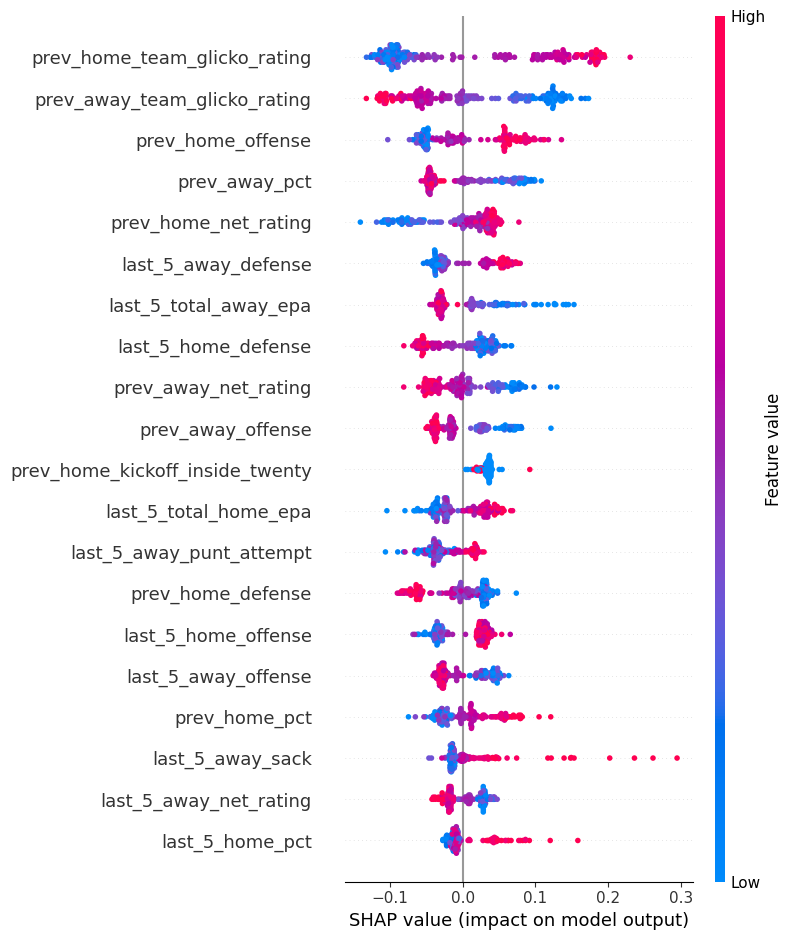

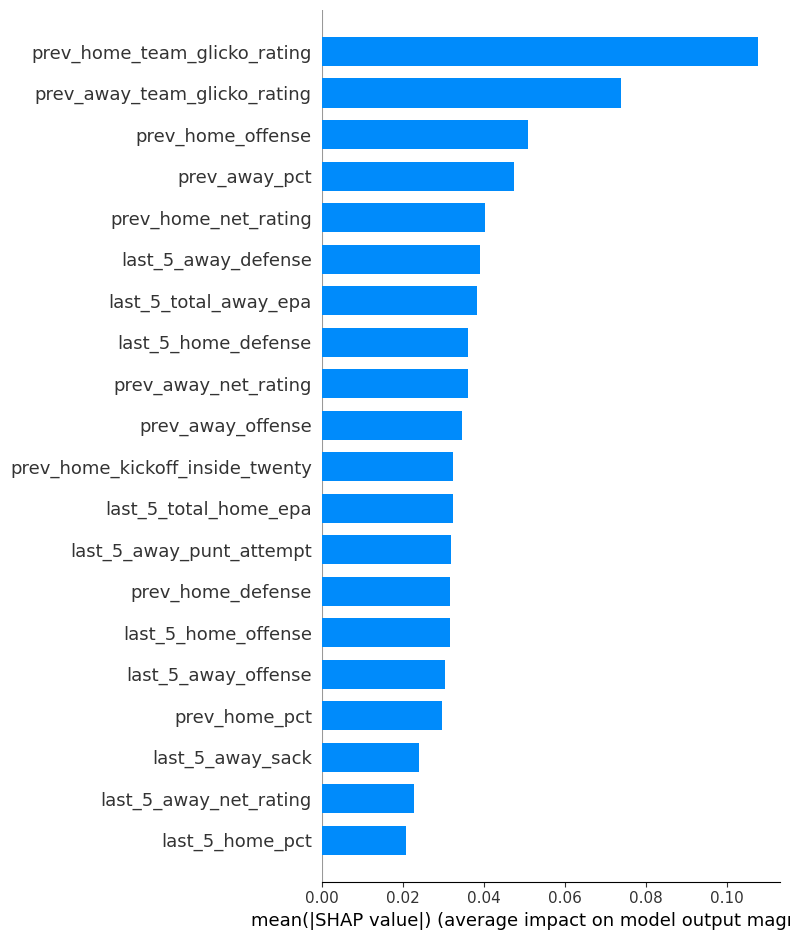

In [30]:
import shap

# SHAP analysis for cat_model_best
# For CatBoost, use TreeExplainer; background sample can be a subset for speed.
X_sample = X_test_scaled[:200] if X_test_scaled.shape[0] > 200 else X_test_scaled

explainer = shap.TreeExplainer(cat_model_best)
shap_values = explainer.shap_values(X_sample)

# Summary plot: the default class is 1 for binary (home win)
shap.summary_plot(shap_values, X_sample, feature_names=X_test.columns, show=True)

# Optionally, display SHAP feature importances as bar plot for class 1
shap.summary_plot(shap_values, X_sample, feature_names=X_test.columns, plot_type="bar", show=True)


In [ ]:
import pandas as pd

def get_shap_feature_df(X: pd.DataFrame, shap_values) -> pd.DataFrame:
    """
    Return a DataFrame with features and their corresponding shap values for each sample.

    Args:
        X (pd.DataFrame): Input features used for SHAP value computation.
        shap_values: SHAP values array (samples x features).

    Returns:
        pd.DataFrame: DataFrame with columns as features and rows as SHAP values.
    """
    shap_df = pd.DataFrame(shap_values, columns=X.columns, index=X.index if hasattr(X, "index") else None)
    return shap_df

# Usage: get a DataFrame of features and their corresponding SHAP values for X_sample
shap_feature_df = get_shap_feature_df(pd.DataFrame(X_sample, columns=X_test.columns), shap_values)

# Display the SHAP value DataFrame for inspection
shap_feature_df.head(20)


,game_stadium,home_team,away_team,home_coach,away_coach,home_win_pct_history,away_win_pct_history,home_team_avg_score_before,away_team_avg_score_before,league_avg_score_before,...,prev_home_team_sov,prev_away_team_sov,prev_home_team_glicko_rating,prev_away_team_glicko_rating,prev_home_team_rd,prev_away_team_rd,prev_home_team_vol,prev_away_team_vol,h2h_home_win_ratio,h2h_away_win_ratio
0,0.00,-0.00,-0.00,-0.01,-0.00,-0.00,-0.04,-0.00,0.01,-0.02,...,-0.06,0.00,0.16,-0.03,0.00,0.00,0.00,0.00,-0.01,0.00
1,-0.01,-0.00,-0.00,-0.00,-0.00,-0.00,-0.01,-0.00,0.01,0.00,...,0.01,0.00,0.03,-0.04,0.00,-0.00,0.00,0.00,-0.02,-0.01
2,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.04,-0.00,-0.00,0.00,...,0.00,0.00,0.01,0.12,0.00,0.00,0.00,0.00,-0.01,0.01
3,-0.00,0.01,-0.00,-0.00,-0.00,-0.00,-0.03,-0.00,0.00,0.00,...,0.01,0.00,-0.08,-0.04,0.00,-0.00,0.00,0.00,-0.01,-0.01
4,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.03,-0.00,0.01,-0.00,...,0.01,0.00,0.07,-0.04,0.00,-0.00,0.00,0.00,-0.02,-0.01
5,-0.00,-0.00,-0.00,0.03,-0.00,-0.00,-0.03,-0.00,0.00,-0.00,...,0.01,0.00,-0.08,-0.05,0.00,-0.00,0.00,0.00,-0.02,-0.00
6,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.04,-0.00,-0.00,-0.00,...,0.01,0.00,0.06,0.09,0.00,0.00,0.00,0.00,-0.01,-0.01
7,-0.00,-0.00,-0.00,-0.00,0.00,-0.01,-0.03,-0.00,-0.02,-0.00,...,0.01,0.00,-0.09,0.05,0.00,-0.00,0.00,0.00,-0.01,-0.00
8,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.03,-0.00,-0.01,0.00,...,0.01,0.00,-0.08,-0.06,0.00,-0.01,0.00,0.00,0.06,0.01
9,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.01,-0.00,0.01,0.00,...,0.01,0.00,0.06,-0.04,0.00,-0.00,0.00,0.00,-0.02,-0.01


In [ ]:
# # type: ignore
# import os, sys
# from dotenv import load_dotenv
# import numpy as np
# import pandas as pd
# from typing import Dict, List, Optional, Any
# BASE_DIR = os.getcwd()
# print("BASE_DIR:", BASE_DIR)
# sys.path.append(os.path.abspath(os.path.join(BASE_DIR, "..", "..")))

# # sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..")))
# from app.pipeline.feature import (add_historical_win_pct, add_pf_pa_by_season,
#  add_home_away_team_avg_scores_before, add_league_avg_score_before,
#   add_home_away_team_avg_stat_before, add_league_avg_stat_before)

# _ = load_dotenv()
# backend_dir = os.path.abspath(os.path.join(os.path.dirname(BASE_DIR), "../.."))

# # backend_dir = os.path.abspath(os.path.join(os.path.dirname(__file__), "../.."))

# # Use step3_nfl_processed_data.csv only - no fallback, no environment variable override
# input_csv_path = os.path.join(backend_dir, "data", "input", "step3_nfl_processed_data.csv")


# def get_last_5_stat_home(temp: pd.DataFrame, home_feature: str, away_feature: str, home_team_name: str, input: Dict[str, Any]) -> Dict[str, Any]:
#     """
#     Calculate the average of the last 5 games' statistics for the home team and update the input dictionary.

#     Parameters:
#     temp (pd.DataFrame): DataFrame containing game data, including 'home_team', 'away_team', 
#                          'game_date', and the statistical features.
#     home_feature (str): Column name for the statistic when the team is playing at home.
#     away_feature (str): Column name for the statistic when the team is playing away.
#     home_team_name (str): Name of the home team for which statistics are calculated.
#     input (dict): Dictionary to update with the calculated average statistic.

#     Returns:
#     dict: Updated input dictionary with the key 'prev_{home_feature}' containing the mean of last 5 games' statistics.
#     """

#     # Sort the DataFrame by game date in descending order (most recent games first)
#     temp: pd.DataFrame = temp.sort_values("game_date", ascending=False)

#     # Filter games where the team was either home or away and take the last 5 games
#     temp = temp[(temp["home_team"] == home_team_name) | (temp["away_team"] == home_team_name)].head()

#     result: List[Any] = []

#     # Iterate through the filtered games to collect relevant statistics
#     for i in temp[["home_team", "away_team", home_feature, away_feature]].itertuples():
#         # If the team played at home, take the home feature value
#         if i.home_team == home_team_name:
#             result.append(getattr(i, home_feature))
        
#         # If the team played away, take the away feature value
#         if i.away_team == home_team_name:
#             result.append(getattr(i, away_feature))

#     # Update the input dictionary with the mean of the last 5 games
#     input[f"prev_{home_feature}"] = [np.mean(result)]

#     # Return the updated input dictionary
#     return input
    

# def get_last_5_stat_away(temp: pd.DataFrame, home_feature: str, away_feature: str, away_team_name: str, input: Dict[str, Any]) -> Dict[str, Any]:
#     temp: pd.DataFrame = temp.sort_values("game_date", ascending=False)
#     temp = temp[(temp["home_team"] == away_team_name) | (temp["away_team"] == away_team_name)].head()

#     result: List[Any] = []

#     for i in temp[["home_team", "away_team", home_feature, away_feature]].itertuples():
#         if i.home_team == away_team_name:
#             result.append(getattr(i, home_feature))
    
#         if i.away_team == away_team_name:
#             result.append(getattr(i, away_feature))

#         input[f"prev_{away_feature}"] = [np.mean(result)]

#     return input
    


# def get_prev_stat_home(temp: pd.DataFrame, home_feature: str, away_feature: str, home_team_name: str, input: Dict[str, Any]) -> Dict[str, Any]:
#     """
#     Calculate the average of the last 5 games' statistics for the away team and update the input dictionary.

#     Parameters:
#     temp (pd.DataFrame): DataFrame containing game data, including 'home_team', 'away_team', 
#                          'game_date', and the statistical features.
#     home_feature (str): Column name for the statistic when the team is playing at home.
#     away_feature (str): Column name for the statistic when the team is playing away.
#     away_team_name (str): Name of the away team for which statistics are calculated.
#     input (dict): Dictionary to update with the calculated average statistic.

#     Returns:
#     dict: Updated input dictionary with the key 'prev_{away_feature}' containing the mean of last 5 games' statistics.

#     """
#     # Sort the DataFrame by game date in descending order (most recent games first)
#     temp: pd.DataFrame = temp.sort_values("game_date", ascending=False)

#     # Filter games where the team was either home or away and take the last 5 games
#     temp = temp[(temp["home_team"] == home_team_name) | (temp["away_team"] == home_team_name)].head(1)

#     result: Optional[Any] = None

#     # Iterate through the filtered games to collect relevant statistics
#     for i in temp[["home_team", "away_team", home_feature, away_feature]].itertuples():

#         # If the team played at home, take the home feature value
#         if i.home_team == home_team_name:
#             result = getattr(i, home_feature)

#         # If the team played away, take the away feature value
#         if i.away_team == home_team_name:
#             result = getattr(i, away_feature)

#         # Update the input dictionary with the mean of the last 5 games
#         input[f"last_5_{home_feature}"] = [result]

#     return input
    


# def get_prev_stat_away(temp: pd.DataFrame, home_feature: str, away_feature: str, away_team_name: str, input: Dict[str, Any]) -> Dict[str, Any]:
#     """
#     Retrieve the statistic from the most recent game for the away team and update the input dictionary.

#     Parameters:
#     temp (pd.DataFrame): DataFrame containing game data, including 'home_team', 'away_team', 
#                          'game_date', and the statistical features.
#     home_feature (str): Column name for the statistic when the team is playing at home.
#     away_feature (str): Column name for the statistic when the team is playing away.
#     away_team_name (str): Name of the away team for which the most recent statistic is retrieved.
#     input (dict): Dictionary to update with the retrieved statistic.

#     Returns:
#     dict: Updated input dictionary with the key 'last_5_{away_feature}' containing the statistic from the most recent game.
    
#     """
#     # Sort the DataFrame by game date in descending order (most recent games first)
#     temp: pd.DataFrame = temp.sort_values("game_date", ascending=False)

#     # Filter games where the team was either home or away and take the most recent game only
#     temp = temp[(temp["home_team"] == away_team_name) | (temp["away_team"] == away_team_name)].head(1)

#     result: Optional[Any] = None

#     # Iterate through the filtered game to get the relevant statistic
#     for i in temp[["home_team", "away_team", home_feature, away_feature]].itertuples():
        
#         # If the team played at home, take the home feature value
#         if i.home_team == away_team_name:
#             result = getattr(i, home_feature)

#         # If the team played away, take the away feature value
#         if i.away_team == away_team_name:
#             result = getattr(i, away_feature)

#         # Update the input dictionary with the statistic from the most recent game
#         input[f"last_5_{away_feature}"] = [result]

#     return input
    




# def get_glicko_rating(cleaned: pd.DataFrame, team_name: str, input: Dict[str, Any], team_type: str) -> Dict[str, Any]:
#     """
#     Retrieve the most recent Glicko rating, rating deviation (RD), and volatility (VOL) 
#     for a given team and update the input dictionary.

#     Parameters:
#     cleaned (pd.DataFrame): DataFrame containing game data including 'home_team', 'away_team',
#                             Glicko ratings ('home_team_glicko_rating', 'away_team_glicko_rating'),
#                             rating deviations ('home_team_rd', 'away_team_rd'), and volatility 
#                             ('home_team_vol', 'away_team_vol').
#     team_name (str): Name of the team to retrieve the most recent Glicko statistics for.
#     input (dict): Dictionary to update with the Glicko statistics.
#     team_type (str): Specifies whether the team is 'home' or 'away', used for naming keys in input.

#     Returns:
#     dict: Updated input dictionary with the most recent Glicko rating, RD, and VOL for the team.

    
#     """
#     #iterate through the recent matches of team
#     for i in cleaned[(cleaned["home_team"] == team_name)  | (cleaned["away_team"] == team_name)].sort_values("game_date", ascending = False).head(1)[["home_team","away_team", "home_team_glicko_rating","away_team_glicko_rating","home_team_rd","away_team_rd","home_team_vol", "away_team_vol"]].itertuples():
        
#         #if team is home team then get values from home_feautes
#         if i.home_team == team_name:
#             input[f"prev_{team_type}_team_glicko_rating"] = [i.home_team_glicko_rating]
#             input[f"prev_{team_type}_team_rd"] = [i.home_team_rd]
#             input[f"prev_{team_type}_team_vol"] = [i.home_team_vol]

#         #if team is away then get values from away features.
#         if i.away_team == team_name:
#             input[f"prev_{team_type}_team_glicko_rating"] = [i.away_team_glicko_rating]
#             input[f"prev_{team_type}_team_rd"] = [i.away_team_rd]
#             input[f"prev_{team_type}_team_vol"] = [i.away_team_vol]

#     # return input dictionary
#     return input




# def get_head_to_head_win_ratio(df: pd.DataFrame, home_team: str, away_team: str, input: Dict[str, Any]) -> Dict[str, Any]:
#     """
#     Calculate the head-to-head win ratio between two teams over their last 5 matches
#     and update the input dictionary.

#     Parameters:
#     df (pd.DataFrame): DataFrame containing game data, including 'home_team', 'away_team',
#                        'total_home_score', 'total_away_score', and 'game_date'.
#     home_team (str): Name of the home team.
#     away_team (str): Name of the away team.
#     input (dict): Dictionary to update with the calculated head-to-head win ratios.

#     Returns:
#     dict: Updated input dictionary with keys 'h2h_home_win_ratio' and 'h2h_away_win_ratio'.
#     """
#     # Filter last 5 matches between the two teams
#     matches: pd.DataFrame = df[((df["home_team"] == home_team) & (df["away_team"] == away_team)) |
#                  ((df["home_team"] == away_team) & (df["away_team"] == home_team))] \
#                  .sort_values("game_date", ascending=False).head()[["home_team", "away_team", "total_home_score", "total_away_score"]]

#     # Initialize win counts
#     win_counts: Dict[str, int] = {home_team: 0, away_team: 0}

#     # Count wins for each team
#     for match in matches.itertuples():
#         for team in [home_team, away_team]:
#             if (match.home_team == team and match.total_home_score > match.total_away_score) or (match.away_team == team and match.total_away_score > match.total_home_score):
#                 win_counts[team] += 1
#             # elif match.away_team == team and match.total_away_score > match.total_home_score:
#             #     win_counts[team] += 1

#     total_wins: int = win_counts[home_team] + win_counts[away_team]

#     # Update input dictionary with ratios
#     if total_wins > 0:
#         input["h2h_home_win_ratio"] = [win_counts[home_team] / total_wins]
#         input["h2h_away_win_ratio"] = [win_counts[away_team] / total_wins]
#     else:
#         input["h2h_home_win_ratio"] = [0]
#         input["h2h_away_win_ratio"] = [0]

#     return input



# def get_inputs(home_team: str, away_team: str, home_coach: str, away_coach: str, game_stadium: str) -> pd.DataFrame:
#     """
#     Generate a feature DataFrame for a given NFL game by aggregating team statistics, 
#     last 5 game averages, Glicko ratings, and head-to-head win ratios.

#     Parameters:
#     home_team (str): Name of the home team.
#     away_team (str): Name of the away team.
#     home_coach (str): Name of the home team coach.
#     away_coach (str): Name of the away team coach.
#     game_stadium (str): Name of the stadium where the game will be played.

#     Returns:
#     pd.DataFrame: A DataFrame containing all features for the model input, including
#                   previous stats, last 5 game averages, Glicko ratings, and H2H ratios.
    
#     """
#     input_data: Dict[str, Any] = {} # Initialize dictionary to store all features

#     # Load processed NFL dataset
#     if not input_csv_path or not os.path.exists("/home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv"):
#         raise FileNotFoundError(
#             f"Input CSV file not found: {input_csv_path}. "
#             f"Please ensure step3_nfl_processed_data.csv exists in data/input/ directory."
#         )
#     df: pd.DataFrame = pd.read_csv("/home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv", low_memory=False)
    



#     team_feature_df: pd.DataFrame = pd.DataFrame(
#         {
#             "home": ['total_home_score', 'total_home_epa', 'total_home_rush_epa', 'total_home_pass_epa', 'home_first_down_rush', 'home_first_down_pass', 'home_third_down_converted', 'home_fourth_down_converted', 'home_interception', 'home_fumble_lost', 'home_fumble_forced', 'home_rush_attempt', 'home_pass_attempt', 'home_pass_touchdown', 'home_qb_dropback', 'home_rush_touchdown', 'home_tackled_for_loss', 'home_qb_hit', 'home_punt_attempt', 'home_kickoff_attempt', 'home_kickoff_inside_twenty', 'home_penalty_yards', 'home_rushing_yards', 'home_passing_yards', 'home_receiving_yards', 'home_yards_gained', 'home_sack', 'home_return_yards_positive', 'home_return_yards_negative', 'home_yards_after_catch_positive', 'home_yards_after_catch_negative','home_pct', 'home_pf', 'home_pa', 'home_team_avg_score', 'home_net_rating', 'home_defense', 'home_offense', 'home_team_peformance', 'home_avg_passing_yards', 'home_avg_receiving_yards', 'home_avg_rushing_yards', 'home_avg_yards_gained'],
#             "away": ['total_away_score', 'total_away_epa', 'total_away_rush_epa', 'total_away_pass_epa', 'away_first_down_rush', 'away_first_down_pass', 'away_third_down_converted', 'away_fourth_down_converted', 'away_interception', 'away_fumble_lost', 'away_fumble_forced', 'away_rush_attempt', 'away_pass_attempt', 'away_pass_touchdown', 'away_qb_dropback', 'away_rush_touchdown', 'away_tackled_for_loss', 'away_qb_hit', 'away_punt_attempt', 'away_kickoff_attempt', 'away_kickoff_inside_twenty', 'away_penalty_yards', 'away_rushing_yards', 'away_passing_yards', 'away_receiving_yards', 'away_yards_gained', 'away_sack', 'away_return_yards_positive', 'away_return_yards_negative', 'away_yards_after_catch_positive', 'away_yards_after_catch_negative','away_pct', 'away_pf', 'away_pa', 'away_team_avg_score', 'away_net_rating', 'away_defense', 'away_offense', 'away_team_peformance', 'away_avg_passing_yards', 'away_avg_receiving_yards', 'away_avg_rushing_yards', 'away_avg_yards_gained']
#         }
#     )

#     # Retrieve previous single-game stats for both home and away teams
#     for i in team_feature_df.itertuples():
#         input_data = get_prev_stat_home(df, i.home, i.away, home_team, input_data)
#         input_data = get_prev_stat_away(df, i.home, i.away, away_team, input_data)

#     # Retrieve last 5 games' average stats for both home and away teams   
#     for i in team_feature_df.itertuples():
#         input_data = get_last_5_stat_home(df, i.home, i.away, home_team, input_data)
#         input_data = get_last_5_stat_away(df, i.home, i.away, away_team, input_data)

#     # Retrieve Glicko ratings for home and away teams
#     input_data = get_glicko_rating(df, home_team, input_data, "home")
#     input_data = get_glicko_rating(df, away_team, input_data, "away")

#     # Retrieve head-to-head win ratios
#     input_data = get_head_to_head_win_ratio(df, home_team, away_team, input_data)

#     # Convert the input dictionary to a DataFrame
#     input_df: pd.DataFrame = pd.DataFrame(input_data)
#     input_df["net_rating_diff"] = np.log((input_df["prev_home_net_rating"] + 1e6) / (input_df["prev_away_net_rating"] + 1e6))
#     # input_df["net_avg_score"] = np.log((input_df["prev_home_team_avg_score"] + 1e6)/ (input_df["prev_away_team_avg_score"] + 1e6))
#     # input_df['net_avg_passing_yards'] = np.log((input_df['prev_home_avg_passing_yards'] + 1e6) / (input_df['prev_away_avg_passing_yards'] + 1e6))
#     # input_df['net_avg_receiving_yards'] = np.log((input_df['prev_home_avg_receiving_yards'] + 1e6) / (input_df['prev_away_avg_receiving_yards'] + 1e6))
#     # input_df['net_avg_rushing_yards'] = np.log((input_df['prev_home_avg_rushing_yards'] + 1e6)/ (input_df['prev_away_avg_rushing_yards'] + 1e6))
#     # input_df['net_avg_yards_gained'] = np.log((input_df['prev_home_avg_yards_gained'] + 1e6)/ (input_df['prev_away_avg_yards_gained'] + 1e6))
  


    
#     # Add game metadata
#     input_df["home_team"] = [home_team]
#     input_df["away_team"] = [away_team]
#     input_df["home_coach"] = [home_coach]
#     input_df["away_coach"] = [away_coach]
#     input_df["game_stadium"] = [game_stadium]


#     input_df = input_df[['game_stadium',
#  'home_team',
#  'away_team',
#  'home_coach',
#  'away_coach',
#  'last_5_total_home_score',
#  'last_5_total_away_score',
#  'last_5_total_home_epa',
#  'last_5_total_away_epa',
#  'last_5_total_home_rush_epa',
#  'last_5_total_away_rush_epa',
#  'last_5_total_home_pass_epa',
#  'last_5_total_away_pass_epa',
#  'last_5_home_first_down_rush',
#  'last_5_away_first_down_rush',
#  'last_5_home_first_down_pass',
#  'last_5_away_first_down_pass',
#  'last_5_home_third_down_converted',
#  'last_5_away_third_down_converted',
#  'last_5_home_fourth_down_converted',
#  'last_5_away_fourth_down_converted',
#  'last_5_home_interception',
#  'last_5_away_interception',
#  'last_5_home_fumble_lost',
#  'last_5_away_fumble_lost',
#  'last_5_home_fumble_forced',
#  'last_5_away_fumble_forced',
#  'last_5_home_rush_attempt',
#  'last_5_away_rush_attempt',
#  'last_5_home_pass_attempt',
#  'last_5_away_pass_attempt',
#  'last_5_home_pass_touchdown',
#  'last_5_away_pass_touchdown',
#  'last_5_home_qb_dropback',
#  'last_5_away_qb_dropback',
#  'last_5_home_rush_touchdown',
#  'last_5_away_rush_touchdown',
#  'last_5_home_tackled_for_loss',
#  'last_5_away_tackled_for_loss',
#  'last_5_home_qb_hit',
#  'last_5_away_qb_hit',
#  'last_5_home_punt_attempt',
#  'last_5_away_punt_attempt',
#  'last_5_home_kickoff_attempt',
#  'last_5_away_kickoff_attempt',
#  'last_5_home_kickoff_inside_twenty',
#  'last_5_away_kickoff_inside_twenty',
#  'last_5_home_penalty_yards',
#  'last_5_away_penalty_yards',
#  'last_5_home_rushing_yards',
#  'last_5_away_rushing_yards',
#  'last_5_home_passing_yards',
#  'last_5_away_passing_yards',
#  'last_5_home_receiving_yards',
#  'last_5_away_receiving_yards',
#  'last_5_home_yards_gained',
#  'last_5_away_yards_gained',
#  'last_5_home_sack',
#  'last_5_away_sack',
#  'last_5_home_return_yards_positive',
#  'last_5_away_return_yards_positive',
#  'last_5_home_return_yards_negative',
#  'last_5_away_return_yards_negative',
#  'last_5_home_yards_after_catch_positive',
#  'last_5_away_yards_after_catch_positive',
#  'last_5_home_yards_after_catch_negative',
#  'last_5_away_yards_after_catch_negative',
#  'last_5_home_pct',
#  'last_5_away_pct',
#  'last_5_home_pf',
#  'last_5_away_pf',
#  'last_5_home_pa',
#  'last_5_away_pa',
#  'last_5_home_team_avg_score',
#  'last_5_away_team_avg_score',
#  'last_5_home_net_rating',
#  'last_5_away_net_rating',
#  'last_5_home_defense',
#  'last_5_away_defense',
#  'last_5_home_offense',
#  'last_5_away_offense',
#  'last_5_home_team_peformance',
#  'last_5_away_team_peformance',
#  'last_5_home_avg_passing_yards',
#  'last_5_away_avg_passing_yards',
#  'last_5_home_avg_receiving_yards',
#  'last_5_away_avg_receiving_yards',
#  'last_5_home_avg_rushing_yards',
#  'last_5_away_avg_rushing_yards',
#  'last_5_home_avg_yards_gained',
#  'last_5_away_avg_yards_gained',
#  'prev_total_home_score',
#  'prev_total_away_score',
#  'prev_total_home_epa',
#  'prev_total_away_epa',
#  'prev_total_home_rush_epa',
#  'prev_total_away_rush_epa',
#  'prev_total_home_pass_epa',
#  'prev_total_away_pass_epa',
#  'prev_home_first_down_rush',
#  'prev_away_first_down_rush',
#  'prev_home_first_down_pass',
#  'prev_away_first_down_pass',
#  'prev_home_third_down_converted',
#  'prev_away_third_down_converted',
#  'prev_home_fourth_down_converted',
#  'prev_away_fourth_down_converted',
#  'prev_home_interception',
#  'prev_away_interception',
#  'prev_home_fumble_lost',
#  'prev_away_fumble_lost',
#  'prev_home_fumble_forced',
#  'prev_away_fumble_forced',
#  'prev_home_rush_attempt',
#  'prev_away_rush_attempt',
#  'prev_home_pass_attempt',
#  'prev_away_pass_attempt',
#  'prev_home_pass_touchdown',
#  'prev_away_pass_touchdown',
#  'prev_home_qb_dropback',
#  'prev_away_qb_dropback',
#  'prev_home_rush_touchdown',
#  'prev_away_rush_touchdown',
#  'prev_home_tackled_for_loss',
#  'prev_away_tackled_for_loss',
#  'prev_home_qb_hit',
#  'prev_away_qb_hit',
#  'prev_home_punt_attempt',
#  'prev_away_punt_attempt',
#  'prev_home_kickoff_attempt',
#  'prev_away_kickoff_attempt',
#  'prev_home_kickoff_inside_twenty',
#  'prev_away_kickoff_inside_twenty',
#  'prev_home_penalty_yards',
#  'prev_away_penalty_yards',
#  'prev_home_rushing_yards',
#  'prev_away_rushing_yards',
#  'prev_home_passing_yards',
#  'prev_away_passing_yards',
#  'prev_home_receiving_yards',
#  'prev_away_receiving_yards',
#  'prev_home_yards_gained',
#  'prev_away_yards_gained',
#  'prev_home_sack',
#  'prev_away_sack',
#  'prev_home_return_yards_positive',
#  'prev_away_return_yards_positive',
#  'prev_home_return_yards_negative',
#  'prev_away_return_yards_negative',
#  'prev_home_yards_after_catch_positive',
#  'prev_away_yards_after_catch_positive',
#  'prev_home_yards_after_catch_negative',
#  'prev_away_yards_after_catch_negative',
#  'prev_home_pct',
#  'prev_away_pct',
#  'prev_home_pf',
#  'prev_away_pf',
#  'prev_home_pa',
#  'prev_away_pa',
#  'prev_home_team_avg_score',
#  'prev_away_team_avg_score',
#  'prev_home_net_rating',
#  'prev_away_net_rating',
#  'prev_home_defense',
#  'prev_away_defense',
#  'prev_home_offense',
#  'prev_away_offense',
#  'prev_home_team_peformance',
#  'prev_away_team_peformance',
#  'prev_home_avg_passing_yards',
#  'prev_away_avg_passing_yards',
#  'prev_home_avg_receiving_yards',
#  'prev_away_avg_receiving_yards',
#  'prev_home_avg_rushing_yards',
#  'prev_away_avg_rushing_yards',
#  'prev_home_avg_yards_gained',
#  'prev_away_avg_yards_gained',
#  'prev_home_team_glicko_rating',
#  'prev_away_team_glicko_rating',
#  'prev_home_team_rd',
#  'prev_away_team_rd',
#  'prev_home_team_vol',
#  'prev_away_team_vol',
#  'h2h_home_win_ratio',
#  'h2h_away_win_ratio',
# #  'net_rating_diff'
# #  'net_avg_score',
# #  'net_avg_passing_yards',
# #  'net_avg_receiving_yards',
# #  'net_avg_rushing_yards',
# #  'net_avg_yards_gained'
# ]]

#     # Reorder columns to match model input expectations
# #     input_df = input_df[['game_stadium', 'home_team', 'away_team',
# #                           'home_coach', 'away_coach', 'last_5_total_home_score', 
# #                           'last_5_total_away_score', 'last_5_total_home_epa', 
# #                           'last_5_total_away_epa', 'last_5_total_home_rush_epa', 
# #                           'last_5_total_away_rush_epa', 'last_5_total_home_pass_epa', 
# #                           'last_5_total_away_pass_epa', 'last_5_home_first_down_rush',
# #                             'last_5_away_first_down_rush', 'last_5_home_first_down_pass',
# #                               'last_5_away_first_down_pass', 'last_5_home_third_down_converted',
# #                                 'last_5_away_third_down_converted',
# #                                   'last_5_home_fourth_down_converted', 
# #                                   'last_5_away_fourth_down_converted', 'last_5_home_interception',
# #                                     'last_5_away_interception', 
# #                                     'last_5_home_fumble_lost', 'last_5_away_fumble_lost',
# #                                       'last_5_home_fumble_forced', 'last_5_away_fumble_forced', 
# #                                       'last_5_home_rush_attempt', 'last_5_away_rush_attempt', 
# #                                       'last_5_home_pass_attempt', 'last_5_away_pass_attempt', 
# #                                       'last_5_home_pass_touchdown', 'last_5_away_pass_touchdown', 
# #                                       'last_5_home_qb_dropback', 'last_5_away_qb_dropback', 'last_5_home_rush_touchdown', 
# #                                       'last_5_away_rush_touchdown', 'last_5_home_tackled_for_loss', 'last_5_away_tackled_for_loss', 
# #                                       'last_5_home_qb_hit', 'last_5_away_qb_hit', 'last_5_home_punt_attempt',
# #                                         'last_5_away_punt_attempt', 'last_5_home_kickoff_attempt',
# #                                           'last_5_away_kickoff_attempt', 'last_5_home_kickoff_inside_twenty',
# #                                             'last_5_away_kickoff_inside_twenty', 'last_5_home_penalty_yards',
# #                                               'last_5_away_penalty_yards', 'last_5_home_rushing_yards',
# #                                                 'last_5_away_rushing_yards', 'last_5_home_passing_yards',
# #                                                   'last_5_away_passing_yards', 'last_5_home_receiving_yards',
# #                                                     'last_5_away_receiving_yards', 'last_5_home_yards_gained',
# #                                                       'last_5_away_yards_gained', 'last_5_home_sack', 'last_5_away_sack',
# #                                                         'last_5_home_return_yards_positive', 'last_5_away_return_yards_positive',
# #                                                           'last_5_home_return_yards_negative', 'last_5_away_return_yards_negative',
# #                                                             'last_5_home_yards_after_catch_positive', 'last_5_away_yards_after_catch_positive',
# #                                                               'last_5_home_yards_after_catch_negative', 'last_5_away_yards_after_catch_negative',
# #                                                                 'prev_total_home_score', 'prev_total_away_score', 'prev_total_home_epa', 'prev_total_away_epa',
# #                                                                   'prev_total_home_rush_epa', 'prev_total_away_rush_epa', 'prev_total_home_pass_epa',
# #                                                                     'prev_total_away_pass_epa', 'prev_home_first_down_rush', 'prev_away_first_down_rush',
# #                                                                       'prev_home_first_down_pass', 'prev_away_first_down_pass',
# #                                                                         'prev_home_third_down_converted', 'prev_away_third_down_converted',
# #                                                                           'prev_home_fourth_down_converted', 'prev_away_fourth_down_converted',
# #                                                                             'prev_home_interception', 'prev_away_interception', 'prev_home_fumble_lost',
# #                                                                               'prev_away_fumble_lost', 'prev_home_fumble_forced', 'prev_away_fumble_forced',
# #                                                                                 'prev_home_rush_attempt', 'prev_away_rush_attempt', 'prev_home_pass_attempt',
# #                                                                                   'prev_away_pass_attempt', 'prev_home_pass_touchdown', 'prev_away_pass_touchdown',
# #                                                                                     'prev_home_qb_dropback', 'prev_away_qb_dropback', 'prev_home_rush_touchdown',
# #                                                                                       'prev_away_rush_touchdown', 'prev_home_tackled_for_loss', 'prev_away_tackled_for_loss',
# #                                                                                         'prev_home_qb_hit', 'prev_away_qb_hit', 'prev_home_punt_attempt', 'prev_away_punt_attempt',
# #                                                                                           'prev_home_kickoff_attempt', 'prev_away_kickoff_attempt', 'prev_home_kickoff_inside_twenty',
# #                                                                                             'prev_away_kickoff_inside_twenty', 'prev_home_penalty_yards', 'prev_away_penalty_yards',
# #                                                                                               'prev_home_rushing_yards', 'prev_away_rushing_yards', 'prev_home_passing_yards', 
# #                                                                                               'prev_away_passing_yards', 'prev_home_receiving_yards', 'prev_away_receiving_yards',
# #                                                                                                 'prev_home_yards_gained', 'prev_away_yards_gained', 'prev_home_sack',
# #                                                                                                   'prev_away_sack', 'prev_home_return_yards_positive', 'prev_away_return_yards_positive',
# #                                                                                                     'prev_home_return_yards_negative', 'prev_away_return_yards_negative', 'prev_home_yards_after_catch_positive',
# #                                                                                                       'prev_away_yards_after_catch_positive', 'prev_home_yards_after_catch_negative', 'prev_away_yards_after_catch_negative',
# #                                                                                                         'prev_home_team_glicko_rating', 'prev_away_team_glicko_rating', 'prev_home_team_rd', 'prev_away_team_rd', 'prev_home_team_vol',
# #                                                                                                           'prev_away_team_vol', 'h2h_home_win_ratio', 'h2h_away_win_ratio']
# # ]

#     return input_df

BASE_DIR: /home/root495/Inexture/nfl-sport-prediction/backend/notebooks


In [24]:
X.columns.tolist()

['game_stadium',
 'home_team',
 'away_team',
 'home_coach',
 'away_coach',
 'last_5_total_home_score',
 'last_5_total_away_score',
 'last_5_total_home_epa',
 'last_5_total_away_epa',
 'last_5_total_home_rush_epa',
 'last_5_total_away_rush_epa',
 'last_5_total_home_pass_epa',
 'last_5_total_away_pass_epa',
 'last_5_home_first_down_rush',
 'last_5_away_first_down_rush',
 'last_5_home_first_down_pass',
 'last_5_away_first_down_pass',
 'last_5_home_third_down_converted',
 'last_5_away_third_down_converted',
 'last_5_home_fourth_down_converted',
 'last_5_away_fourth_down_converted',
 'last_5_home_interception',
 'last_5_away_interception',
 'last_5_home_fumble_lost',
 'last_5_away_fumble_lost',
 'last_5_home_fumble_forced',
 'last_5_away_fumble_forced',
 'last_5_home_rush_attempt',
 'last_5_away_rush_attempt',
 'last_5_home_pass_attempt',
 'last_5_away_pass_attempt',
 'last_5_home_pass_touchdown',
 'last_5_away_pass_touchdown',
 'last_5_home_qb_dropback',
 'last_5_away_qb_dropback',
 'last_

In [ ]:
import pickle
with open("/home/root495/Inexture/nfl-sport-prediction/backend/models/cat_model_best.pkl", "wb") as f:
    pickle.dump(cat_model, f)

# with open("/home/root495/Inexture/nfl-sport-prediction/models/random_forest_model.pkl", "wb") as f:
#     pickle.dump(model, f)

with open("/home/root495/Inexture/nfl-sport-prediction/backend/models/coach_encoder.pkl", "wb") as f:
    pickle.dump(coach_le, f)

with open("/home/root495/Inexture/nfl-sport-prediction/backend/models/ground_encoder.pkl", "wb") as f:
    pickle.dump(ground_le, f)
with open("/home/root495/Inexture/nfl-sport-prediction/backend/models/team_encoder.pkl", "wb") as f:
    pickle.dump(team_le, f)

with open("/home/root495/Inexture/nfl-sport-prediction/backend/models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [33]:
# import sys, os
# sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

# from app.pipeline.inference import get_inputs


import pickle
import nfl_data_py as nfl


# with open("/home/root495/Inexture/nfl-sport-prediction/backend/models/coach_encoder.pkl", "rb") as f:
#     coach_le = pickle.load(f)

# with open("/home/root495/Inexture/nfl-sport-prediction/backend/models/team_encoder.pkl", "rb") as f:
#     team_le = pickle.load(f)

# with open("/home/root495/Inexture/nfl-sport-prediction/backend/models/ground_encoder.pkl", "rb") as f:
#     ground_le = pickle.load(f)

# with open("/home/root495/Inexture/nfl-sport-prediction/backend/models/scaler.pkl", "rb") as f:
#     scaler = pickle.load(f)
# model = None
# with open("/home/root495/Inexture/nfl-sport-prediction/backend/models/cat_model.pkl", "rb") as f:
#     model = pickle.load(f)


In [64]:
from sklearn.metrics import classification_report

# Make predictions with cat_model_best using the default threshold (0.5)
y_pred_best = model.predict(X_test_scaled, )

# Generate and print the classification report
cat_best_report = classification_report(y_test, y_pred_best, digits=4)
print("Classification Report (CatBoost Best):")
print(cat_best_report)

NameError: name 'model' is not defined

In [96]:
import nfl_data_py as nfl
data = nfl.import_pbp_data([2025])



2025 done.
Downcasting floats.


In [97]:
data

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,1.00,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,None,None,None,...,0.00,0.00,-0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40.00,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0.00,0.00,-0.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,63.00,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0.00,0.00,-0.19,NaN,NaN,NaN,NaN,NaN,0.51,-51.11
3,85.00,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,1.00,0.00,1.32,0.94,4.75,3.00,0.67,0.44,0.67,33.11
4,115.00,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0.00,0.00,-1.69,NaN,NaN,NaN,NaN,NaN,0.49,50.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47493,4127.00,2025_19_SF_PHI,2026011101,PHI,SF,POST,19,None,None,None,...,0.00,0.00,-0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47494,4115.00,2025_19_SF_PHI,2026011101,PHI,SF,POST,19,SF,away,PHI,...,0.00,0.00,-0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47495,4156.00,2025_19_SF_PHI,2026011101,PHI,SF,POST,19,None,None,None,...,0.00,0.00,-0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47496,4144.00,2025_19_SF_PHI,2026011101,PHI,SF,POST,19,SF,away,PHI,...,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from app.pipeline.inference import get_inputs 

In [50]:
from app.pipeline.inference import get_inputs 

In [39]:
# export_data = {
#     "home_team": [],
#     "away_team": [],
#     "home_win": [],
#     "away_win": [],
#     "result": [],
#     "model_result": []
# }
# for i in data[(data["game_seconds_remaining"] == 0) & (data["week"] == 12)].sort_values(by="game_date", ascending=False)[["home_team","away_team", "home_coach", "away_coach", "game_stadium","total_home_score", "total_away_score"]].itertuples():
#     input_df = get_inputs(i.home_team, i.away_team, i.home_coach,i.away_coach, i.game_stadium)
#     input_df["home_team"] = team_le.transform(input_df["home_team"])
#     input_df["away_team"] = team_le.transform(input_df["away_team"])
#     input_df["home_coach"] = coach_le.transform(input_df["home_coach"])
#     input_df["away_coach"] = coach_le.transform(input_df["away_coach"])
#     input_df["game_stadium"] = ground_le.transform(input_df["game_stadium"])
#     input_df = scaler.transform(input_df)

#     export_data["home_team"].append(i.home_team)
#     export_data["away_team"].append(i.away_team)
#     # print(cat_model_best.predict_proba(input_df))

#     export_data["home_win"].append(ann_model.predict(input_df)[0][0])
#     print(model.predict(input_df))
#     export_data["away_win"].append( 1- ann_model.predict(input_df)[0][0])
#     export_data["result"].append(int(i.total_home_score > i.total_away_score))
#     export_data["model_result"].append(ann_model.predict(input_df)[0][0])
#     # print(model.predict_proba(input_df)[0][0])


In [105]:
export_data = {
    "home_team": [],
    "away_team": [],
    "home_win": [],
    "away_win": [],
    "result": [],
    "model_result": []
}
for i in data[(data["game_seconds_remaining"] == 0) & (data["season_type"] == "REG")].sort_values(by="game_date", ascending=False)[["home_team","away_team", "home_coach", "away_coach", "game_stadium","total_home_score", "total_away_score"]].itertuples():
    input_df = get_inputs(i.home_team, i.away_team, i.home_coach,i.away_coach, i.game_stadium)
    # print(input_df.columns.tolist())
    input_df["home_team"] = team_le.transform(input_df["home_team"])
    input_df["away_team"] = team_le.transform(input_df["away_team"])
    input_df["home_coach"] = coach_le.transform(input_df["home_coach"])
    input_df["away_coach"] = coach_le.transform(input_df["away_coach"])
    input_df["game_stadium"] = ground_le.transform(input_df["game_stadium"])
    input_df = scaler.transform(input_df)
    export_data["home_team"].append(i.home_team)
    export_data["away_team"].append(i.away_team)
    # print(cat_model_best.predict_proba(input_df))

    export_data["home_win"].append(cat_model_best.predict_proba(input_df)[0][1])
    print(cat_model_best.predict_proba(input_df))
    export_data["away_win"].append( cat_model_best.predict_proba(input_df)[0][0])
    export_data["result"].append(int(i.total_home_score > i.total_away_score))
    export_data["model_result"].append(cat_model_best.predict_proba(input_df)[0][1])
    
    # print(model.predict_proba(input_df)[0][0])
# & (data["week"] == 15)
# & (data["week"] >= 1) & (data["week"] <= 18)

Generating inputs for PHI vs WAS...
Loading data from /home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv...
[[0.30879145 0.69120855]]
Generating inputs for LV vs KC...
Loading data from /home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv...
[[0.61748745 0.38251255]]
Generating inputs for LA vs ARI...
Loading data from /home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv...
[[0.27795786 0.72204214]]
Generating inputs for PIT vs BAL...
Loading data from /home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv...
[[0.45837772 0.54162228]]
Generating inputs for CIN vs CLE...
Loading data from /home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv...
[[0.46264856 0.53735144]]
Generating inputs for NYG vs DAL...
Loading data from /home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_p

In [98]:
print(X.columns.tolist())

['game_stadium', 'home_team', 'away_team', 'home_coach', 'away_coach', 'last_5_total_home_score', 'last_5_total_away_score', 'last_5_total_home_epa', 'last_5_total_away_epa', 'last_5_total_home_rush_epa', 'last_5_total_away_rush_epa', 'last_5_total_home_pass_epa', 'last_5_total_away_pass_epa', 'last_5_home_first_down_rush', 'last_5_away_first_down_rush', 'last_5_home_first_down_pass', 'last_5_away_first_down_pass', 'last_5_home_third_down_converted', 'last_5_away_third_down_converted', 'last_5_home_fourth_down_converted', 'last_5_away_fourth_down_converted', 'last_5_home_interception', 'last_5_away_interception', 'last_5_home_fumble_lost', 'last_5_away_fumble_lost', 'last_5_home_fumble_forced', 'last_5_away_fumble_forced', 'last_5_home_rush_attempt', 'last_5_away_rush_attempt', 'last_5_home_pass_attempt', 'last_5_away_pass_attempt', 'last_5_home_pass_touchdown', 'last_5_away_pass_touchdown', 'last_5_home_qb_dropback', 'last_5_away_qb_dropback', 'last_5_home_rush_touchdown', 'last_5_awa

In [ ]:
['game_stadium', 'home_team', 'away_team', 'home_coach', 'away_coach', 'last_5_total_home_score', 'last_5_total_away_score', 'last_5_total_home_epa', 'last_5_total_away_epa', 'last_5_total_home_rush_epa', 'last_5_total_away_rush_epa', 'last_5_total_home_pass_epa', 'last_5_total_away_pass_epa', 'last_5_home_first_down_rush', 'last_5_away_first_down_rush', 'last_5_home_first_down_pass', 'last_5_away_first_down_pass', 'last_5_home_third_down_converted', 'last_5_away_third_down_converted', 'last_5_home_fourth_down_converted', 'last_5_away_fourth_down_converted', 'last_5_home_interception', 'last_5_away_interception', 'last_5_home_fumble_lost', 'last_5_away_fumble_lost', 'last_5_home_fumble_forced', 'last_5_away_fumble_forced', 'last_5_home_rush_attempt', 'last_5_away_rush_attempt', 'last_5_home_pass_attempt', 'last_5_away_pass_attempt', 'last_5_home_pass_touchdown', 'last_5_away_pass_touchdown', 'last_5_home_qb_dropback', 'last_5_away_qb_dropback', 'last_5_home_rush_touchdown', 'last_5_away_rush_touchdown', 'last_5_home_tackled_for_loss', 'last_5_away_tackled_for_loss', 'last_5_home_qb_hit', 'last_5_away_qb_hit', 'last_5_home_punt_attempt', 'last_5_away_punt_attempt', 'last_5_home_kickoff_attempt', 'last_5_away_kickoff_attempt', 'last_5_home_kickoff_inside_twenty', 'last_5_away_kickoff_inside_twenty', 'last_5_home_penalty_yards', 'last_5_away_penalty_yards', 'last_5_home_rushing_yards', 'last_5_away_rushing_yards', 'last_5_home_passing_yards', 'last_5_away_passing_yards', 'last_5_home_receiving_yards', 'last_5_away_receiving_yards', 'last_5_home_yards_gained', 'last_5_away_yards_gained', 'last_5_home_sack', 'last_5_away_sack', 'last_5_home_return_yards_positive', 'last_5_away_return_yards_positive', 'last_5_home_return_yards_negative', 'last_5_away_return_yards_negative', 'last_5_home_yards_after_catch_positive', 'last_5_away_yards_after_catch_positive', 'last_5_home_yards_after_catch_negative', 'last_5_away_yards_after_catch_negative', 'last_5_home_pct', 'last_5_away_pct', 'last_5_home_pf', 'last_5_away_pf', 'last_5_home_pa', 'last_5_away_pa', 'last_5_home_team_avg_score', 'last_5_away_team_avg_score', 'last_5_home_net_rating', 'last_5_away_net_rating', 'last_5_home_defense', 'last_5_away_defense', 'last_5_home_offense', 'last_5_away_offense', 'last_5_home_team_peformance', 'last_5_away_team_peformance', 'last_5_home_avg_passing_yards', 'last_5_away_avg_passing_yards', 'last_5_home_avg_receiving_yards', 'last_5_away_avg_receiving_yards', 'last_5_home_avg_rushing_yards', 'last_5_away_avg_rushing_yards', 'last_5_home_avg_yards_gained', 'last_5_away_avg_yards_gained', 'prev_total_home_score', 'prev_total_away_score', 'prev_total_home_epa', 'prev_total_away_epa', 'prev_total_home_rush_epa', 'prev_total_away_rush_epa', 'prev_total_home_pass_epa', 'prev_total_away_pass_epa', 'prev_home_first_down_rush', 'prev_away_first_down_rush', 'prev_home_first_down_pass', 'prev_away_first_down_pass', 'prev_home_third_down_converted', 'prev_away_third_down_converted', 'prev_home_fourth_down_converted', 'prev_away_fourth_down_converted', 'prev_home_interception', 'prev_away_interception', 'prev_home_fumble_lost', 'prev_away_fumble_lost', 'prev_home_fumble_forced', 'prev_away_fumble_forced', 'prev_home_rush_attempt', 'prev_away_rush_attempt', 'prev_home_pass_attempt', 'prev_away_pass_attempt', 'prev_home_pass_touchdown', 'prev_away_pass_touchdown', 'prev_home_qb_dropback', 'prev_away_qb_dropback', 'prev_home_rush_touchdown', 'prev_away_rush_touchdown', 'prev_home_tackled_for_loss', 'prev_away_tackled_for_loss', 'prev_home_qb_hit', 'prev_away_qb_hit', 'prev_home_punt_attempt', 'prev_away_punt_attempt', 'prev_home_kickoff_attempt', 'prev_away_kickoff_attempt', 'prev_home_kickoff_inside_twenty', 'prev_away_kickoff_inside_twenty', 'prev_home_penalty_yards', 'prev_away_penalty_yards', 'prev_home_rushing_yards', 'prev_away_rushing_yards', 'prev_home_passing_yards', 'prev_away_passing_yards', 'prev_home_receiving_yards', 'prev_away_receiving_yards', 'prev_home_yards_gained', 'prev_away_yards_gained', 'prev_home_sack', 'prev_away_sack', 'prev_home_return_yards_positive', 'prev_away_return_yards_positive', 'prev_home_return_yards_negative', 'prev_away_return_yards_negative', 'prev_home_yards_after_catch_positive', 'prev_away_yards_after_catch_positive', 'prev_home_yards_after_catch_negative', 'prev_away_yards_after_catch_negative', 'prev_home_pct', 'prev_away_pct', 'prev_home_pf', 'prev_away_pf', 'prev_home_pa', 'prev_away_pa', 'prev_home_team_avg_score', 'prev_away_team_avg_score', 'prev_home_net_rating', 'prev_away_net_rating', 'prev_home_defense', 'prev_away_defense', 'prev_home_offense', 'prev_away_offense', 'prev_home_team_peformance', 'prev_away_team_peformance', 'prev_home_avg_passing_yards', 'prev_away_avg_passing_yards', 'prev_home_avg_receiving_yards', 'prev_away_avg_receiving_yards', 'prev_home_avg_rushing_yards', 'prev_away_avg_rushing_yards', 'prev_home_avg_yards_gained', 'prev_away_avg_yards_gained', 'prev_home_team_glicko_rating', 'prev_away_team_glicko_rating', 'prev_home_team_rd', 'prev_away_team_rd', 'prev_home_team_vol', 'prev_away_team_vol', 'h2h_home_win_ratio', 'h2h_away_win_ratio']
['game_stadium', 'home_team', 'away_team', 'home_coach', 'away_coach', 'last_5_total_home_score', 'last_5_total_away_score', 'last_5_total_home_epa', 'last_5_total_away_epa', 'last_5_total_home_rush_epa', 'last_5_total_away_rush_epa', 'last_5_total_home_pass_epa', 'last_5_total_away_pass_epa', 'last_5_home_first_down_rush', 'last_5_away_first_down_rush', 'last_5_home_first_down_pass', 'last_5_away_first_down_pass', 'last_5_home_third_down_converted', 'last_5_away_third_down_converted', 'last_5_home_fourth_down_converted', 'last_5_away_fourth_down_converted', 'last_5_home_interception', 'last_5_away_interception', 'last_5_home_fumble_lost', 'last_5_away_fumble_lost', 'last_5_home_fumble_forced', 'last_5_away_fumble_forced', 'last_5_home_rush_attempt', 'last_5_away_rush_attempt', 'last_5_home_pass_attempt', 'last_5_away_pass_attempt', 'last_5_home_pass_touchdown', 'last_5_away_pass_touchdown', 'last_5_home_qb_dropback', 'last_5_away_qb_dropback', 'last_5_home_rush_touchdown', 'last_5_away_rush_touchdown', 'last_5_home_tackled_for_loss', 'last_5_away_tackled_for_loss', 'last_5_home_qb_hit', 'last_5_away_qb_hit', 'last_5_home_punt_attempt', 'last_5_away_punt_attempt', 'last_5_home_kickoff_attempt', 'last_5_away_kickoff_attempt', 'last_5_home_kickoff_inside_twenty', 'last_5_away_kickoff_inside_twenty', 'last_5_home_penalty_yards', 'last_5_away_penalty_yards', 'last_5_home_rushing_yards', 'last_5_away_rushing_yards', 'last_5_home_passing_yards', 'last_5_away_passing_yards', 'last_5_home_receiving_yards', 'last_5_away_receiving_yards', 'last_5_home_yards_gained', 'last_5_away_yards_gained', 'last_5_home_sack', 'last_5_away_sack', 'last_5_home_return_yards_positive', 'last_5_away_return_yards_positive', 'last_5_home_return_yards_negative', 'last_5_away_return_yards_negative', 'last_5_home_yards_after_catch_positive', 'last_5_away_yards_after_catch_positive', 'last_5_home_yards_after_catch_negative', 'last_5_away_yards_after_catch_negative', 'last_5_home_pct', 'last_5_away_pct', 'last_5_home_pf', 'last_5_away_pf', 'last_5_home_pa', 'last_5_away_pa', 'last_5_home_team_avg_score', 'last_5_away_team_avg_score', 'last_5_home_net_rating', 'last_5_away_net_rating', 'last_5_home_defense', 'last_5_away_defense', 'last_5_home_offense', 'last_5_away_offense', 'last_5_home_team_peformance', 'last_5_away_team_peformance', 'last_5_home_avg_passing_yards', 'last_5_away_avg_passing_yards', 'last_5_home_avg_receiving_yards', 'last_5_away_avg_receiving_yards', 'last_5_home_avg_rushing_yards', 'last_5_away_avg_rushing_yards', 'last_5_home_avg_yards_gained', 'last_5_away_avg_yards_gained', 'prev_total_home_score', 'prev_total_away_score', 'prev_total_home_epa', 'prev_total_away_epa', 'prev_total_home_rush_epa', 'prev_total_away_rush_epa', 'prev_total_home_pass_epa', 'prev_total_away_pass_epa', 'prev_home_first_down_rush', 'prev_away_first_down_rush', 'prev_home_first_down_pass', 'prev_away_first_down_pass', 'prev_home_third_down_converted', 'prev_away_third_down_converted', 'prev_home_fourth_down_converted', 'prev_away_fourth_down_converted', 'prev_home_interception', 'prev_away_interception', 'prev_home_fumble_lost', 'prev_away_fumble_lost', 'prev_home_fumble_forced', 'prev_away_fumble_forced', 'prev_home_rush_attempt', 'prev_away_rush_attempt', 'prev_home_pass_attempt', 'prev_away_pass_attempt', 'prev_home_pass_touchdown', 'prev_away_pass_touchdown', 'prev_home_qb_dropback', 'prev_away_qb_dropback', 'prev_home_rush_touchdown', 'prev_away_rush_touchdown', 'prev_home_tackled_for_loss', 'prev_away_tackled_for_loss', 'prev_home_qb_hit', 'prev_away_qb_hit', 'prev_home_punt_attempt', 'prev_away_punt_attempt', 'prev_home_kickoff_attempt', 'prev_away_kickoff_attempt', 'prev_home_kickoff_inside_twenty', 'prev_away_kickoff_inside_twenty', 'prev_home_penalty_yards', 'prev_away_penalty_yards', 'prev_home_rushing_yards', 'prev_away_rushing_yards', 'prev_home_passing_yards', 'prev_away_passing_yards', 'prev_home_receiving_yards', 'prev_away_receiving_yards', 'prev_home_yards_gained', 'prev_away_yards_gained', 'prev_home_sack', 'prev_away_sack', 'prev_home_return_yards_positive', 'prev_away_return_yards_positive', 'prev_home_return_yards_negative', 'prev_away_return_yards_negative', 'prev_home_yards_after_catch_positive', 'prev_away_yards_after_catch_positive', 'prev_home_yards_after_catch_negative', 'prev_away_yards_after_catch_negative', 'prev_home_team_glicko_rating', 'prev_away_team_glicko_rating', 'prev_home_team_rd', 'prev_away_team_rd', 'prev_home_team_vol', 'prev_away_team_vol', 'prev_home_pct', 'prev_away_pct', 'prev_home_pf', 'prev_away_pf', 'prev_home_pa', 'prev_away_pa', 'prev_home_team_avg_score', 'prev_away_team_avg_score', 'prev_home_net_rating', 'prev_away_net_rating', 'prev_home_defense', 'prev_away_defense', 'prev_home_offense', 'prev_away_offense', 'prev_home_team_peformance', 'prev_away_team_peformance', 'prev_home_avg_passing_yards', 'prev_away_avg_passing_yards', 'prev_home_avg_receiving_yards', 'prev_away_avg_receiving_yards', 'prev_home_avg_rushing_yards', 'prev_away_avg_rushing_yards', 'prev_home_avg_yards_gained', 'prev_away_avg_yards_gained', 'h2h_home_win_ratio', 'h2h_away_win_ratio']

In [110]:
export_data = {
    "home_team": [],
    "away_team": [],
    "home_win": [],
    "away_win": [],
    "result": [],
    "model_result": []
}
for i in data[(data["game_seconds_remaining"] == 0) & (data["season_type"] == "REG")].sort_values(by="game_date", ascending=False)[["home_team","away_team", "home_coach", "away_coach", "game_stadium","total_home_score", "total_away_score"]].itertuples():
    input_df = get_inputs(i.home_team, i.away_team, i.home_coach,i.away_coach, i.game_stadium)
    input_df["home_team"] = team_le.transform(input_df["home_team"])
    input_df["away_team"] = team_le.transform(input_df["away_team"])
    input_df["home_coach"] = coach_le.transform(input_df["home_coach"])
    input_df["away_coach"] = coach_le.transform(input_df["away_coach"])
    input_df["game_stadium"] = ground_le.transform(input_df["game_stadium"])
    input_df = scaler.transform(input_df)

    export_data["home_team"].append(i.home_team)
    export_data["away_team"].append(i.away_team)
    # print(cat_model_best.predict_proba(input_df))

    export_data["home_win"].append(rf_best.predict_proba(input_df)[0][1])
    print(rf_best.predict_proba(input_df))
    export_data["away_win"].append( rf_best.predict_proba(input_df)[0][0])
    export_data["result"].append(int(i.total_home_score > i.total_away_score))
    export_data["model_result"].append(rf_best.predict_proba(input_df)[0][1])
    # print(model.predict_proba(input_df)[0][0])
# & (data["week"] == 15)


Generating inputs for PHI vs WAS...
Loading data from /home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv...
[[0.28407634 0.71592366]]
Generating inputs for LV vs KC...
Loading data from /home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv...
[[0.69755788 0.30244212]]
Generating inputs for LA vs ARI...
Loading data from /home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv...
[[0.16792804 0.83207196]]
Generating inputs for PIT vs BAL...
Loading data from /home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv...
[[0.48599489 0.51400511]]
Generating inputs for CIN vs CLE...
Loading data from /home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_processed_data.csv...
[[0.31820254 0.68179746]]
Generating inputs for NYG vs DAL...
Loading data from /home/root495/Inexture/nfl-sport-prediction/backend/data/input/step3_nfl_p

In [111]:
import pandas as pd
export_data_df = pd.DataFrame(export_data)

In [112]:
export_data_df["model_result"] = (export_data_df["home_win"] > export_data_df["away_win"]).astype(int)

In [113]:
export_data_df

,home_team,away_team,home_win,away_win,result,model_result
0,PHI,WAS,0.72,0.28,0,1
1,LV,KC,0.30,0.70,1,0
2,LA,ARI,0.83,0.17,1,1
3,PIT,BAL,0.51,0.49,1,1
4,CIN,CLE,0.68,0.32,0,1
...,...,...,...,...,...,...
270,ATL,TB,0.47,0.53,0,0
271,DEN,TEN,0.83,0.17,1,1
272,NO,ARI,0.70,0.30,0,1
273,LAC,KC,0.52,0.48,1,1


In [114]:
(export_data_df["result"] == export_data_df["model_result"]).sum()

192

In [44]:
export_data_df[(export_data_df["result"] != export_data_df["model_result"])]
# export_data_df

,home_team,away_team,home_win,away_win,result,model_result
1,JAX,BUF,0.51,0.49,0,1
3,PHI,SF,0.56,0.44,0,1
4,CHI,GB,0.46,0.54,1,0


In [46]:
export_data_df

,home_team,away_team,home_win,away_win,result,model_result
0,PIT,HOU,0.50,0.50,0,0
1,JAX,BUF,0.51,0.49,0,1
2,NE,LAC,0.63,0.37,1,1
3,PHI,SF,0.56,0.44,0,1
4,CHI,GB,0.46,0.54,1,0
5,CAR,LA,0.35,0.65,0,0


In [62]:
data[data["away_team"] == "KC"]

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
1187,1.00,2025_01_KC_LAC,2025090500,LAC,KC,REG,1,None,None,None,...,0.00,0.00,-0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1188,40.00,2025_01_KC_LAC,2025090500,LAC,KC,REG,1,KC,away,LAC,...,1.00,0.00,-0.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1189,79.00,2025_01_KC_LAC,2025090500,LAC,KC,REG,1,KC,away,LAC,...,0.00,0.00,-0.01,NaN,NaN,NaN,NaN,NaN,0.49,-48.95
1190,101.00,2025_01_KC_LAC,2025090500,LAC,KC,REG,1,KC,away,LAC,...,0.00,0.00,-0.81,NaN,NaN,NaN,NaN,NaN,0.62,-62.21
1191,123.00,2025_01_KC_LAC,2025090500,LAC,KC,REG,1,KC,away,LAC,...,0.00,0.00,-1.57,1.78,4.31,2.00,0.56,0.56,0.98,1.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45325,4095.00,2025_18_KC_LV,2026010408,LV,KC,REG,18,LV,home,KC,...,0.00,0.00,1.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45326,4115.00,2025_18_KC_LV,2026010408,LV,KC,REG,18,KC,away,LV,...,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45327,4132.00,2025_18_KC_LV,2026010408,LV,KC,REG,18,KC,away,LV,...,0.00,0.00,-0.05,0.12,4.04,2.00,1.00,0.27,0.98,2.41
45328,4155.00,2025_18_KC_LV,2026010408,LV,KC,REG,18,KC,away,LV,...,1.00,0.00,-0.08,0.32,4.60,3.00,1.00,0.31,0.97,3.28


In [44]:
data[data["home_team"] == "IND"]

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
1540,1.00,2025_01_MIA_IND,2025090702,IND,MIA,REG,1,None,None,None,...,0.00,1.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1541,40.00,2025_01_MIA_IND,2025090702,IND,MIA,REG,1,IND,home,MIA,...,0.00,1.00,0.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1542,63.00,2025_01_MIA_IND,2025090702,IND,MIA,REG,1,IND,home,MIA,...,1.00,1.00,0.88,0.72,5.55,4.00,0.64,0.23,0.49,51.27
1543,93.00,2025_01_MIA_IND,2025090702,IND,MIA,REG,1,IND,home,MIA,...,0.00,1.00,-0.54,1.12,9.75,8.00,0.49,0.25,0.44,55.67
1544,116.00,2025_01_MIA_IND,2025090702,IND,MIA,REG,1,IND,home,MIA,...,0.00,1.00,0.26,0.86,4.72,3.00,0.46,0.28,0.52,47.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42502,4085.00,2025_17_JAX_IND,2025122806,IND,JAX,REG,17,IND,home,JAX,...,0.00,1.00,0.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42503,4102.00,2025_17_JAX_IND,2025122806,IND,JAX,REG,17,IND,home,JAX,...,0.00,1.00,-0.19,0.53,6.84,4.00,1.00,1.00,1.00,0.38
42504,4125.00,2025_17_JAX_IND,2025122806,IND,JAX,REG,17,IND,home,JAX,...,0.00,1.00,0.35,0.14,3.44,1.00,1.00,0.49,1.00,0.47
42505,4161.00,2025_17_JAX_IND,2025122806,IND,JAX,REG,17,IND,home,JAX,...,0.00,1.00,-0.47,NaN,NaN,NaN,NaN,NaN,1.00,0.35


In [ ]:
from sklearn.metrics import roc_auc_score

def compute_roc_auc_score_from_model(
    model,
    X_test_scaled: pd.DataFrame,
    y_test: pd.Series
) -> float:
    """
    Compute ROC AUC score of the model on the provided test data.

    Args:
        model: Trained classification model with predict_proba method.
        X_test_scaled (pd.DataFrame): Scaled test feature set.
        y_test (pd.Series): True test labels.

    Returns:
        float: ROC AUC score.
    """
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    return roc_auc_score(y_test, y_pred_proba)

roc_auc = compute_roc_auc_score_from_model(model, X_test_scaled, y_test)
print(f"ROC AUC score on X_test_scaled, y_test: {roc_auc:.4f}")

NameError: name 'model' is not defined

In [ ]:
import nflreadpy as nfl
data = nfl.load_pbp(2025)
data.head()


play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,side_of_field,yardline_100,game_date,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,game_half,quarter_end,drive,sp,qtr,down,goal_to_go,time,yrdln,ydstogo,ydsnet,desc,play_type,yards_gained,shotgun,no_huddle,qb_dropback,qb_kneel,qb_spike,qb_scramble,pass_length,…,home_coach,away_coach,stadium_id,game_stadium,aborted_play,success,passer,passer_jersey_number,rusher,rusher_jersey_number,receiver,receiver_jersey_number,pass,rush,first_down,special,play,passer_id,rusher_id,receiver_id,name,jersey_number,id,fantasy_player_name,fantasy_player_id,fantasy,fantasy_id,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
f64,str,str,str,str,str,i32,str,str,str,str,f64,str,f64,f64,f64,str,f64,f64,f64,f64,f64,i32,str,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,str,…,str,str,str,str,f64,f64,str,i32,str,i32,str,i32,f64,f64,f64,f64,f64,str,str,str,str,i32,str,str,str,str,str,f64,f64,f64,f64,f64,i32,f64,f64,f64,f64
1.0,"""2025_01_ARI_NO""","""2025090705""","""NO""","""ARI""","""REG""",1,null,null,null,null,null,"""2025-09-07""",900.0,1800.0,3600.0,"""Half1""",0.0,null,0.0,1.0,null,0,"""15:00""","""NO 35""",0.0,null,"""GAME""",null,null,0.0,0.0,null,0.0,0.0,0.0,null,…,"""Kellen Moore""","""Jonathan Gannon""","""NOR00""","""Mercedes-Benz Superdome""",0.0,0.0,null,null,null,null,null,null,0.0,0.0,null,0.0,0.0,null,null,null,null,null,null,null,null,null,null,0.0,0.0,-0.0,null,null,null,null,null,null,null
40.0,"""2025_01_ARI_NO""","""2025090705""","""NO""","""ARI""","""REG""",1,"""ARI""","""away""","""NO""","""NO""",35.0,"""2025-09-07""",900.0,1800.0,3600.0,"""Half1""",0.0,1.0,0.0,1.0,null,0,"""15:00""","""NO 35""",0.0,2.0,"""19-B.Grupe kicks 65 yards from…","""kickoff""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,…,"""Kellen Moore""","""Jonathan Gannon""","""NOR00""","""Mercedes-Benz Superdome""",0.0,0.0,null,null,null,null,null,null,0.0,0.0,0.0,1.0,0.0,null,null,null,null,null,null,null,null,null,null,0.0,0.0,-0.3527,null,null,null,null,null,null,null
63.0,"""2025_01_ARI_NO""","""2025090705""","""NO""","""ARI""","""REG""",1,"""ARI""","""away""","""NO""","""ARI""",78.0,"""2025-09-07""",896.0,1796.0,3596.0,"""Half1""",0.0,1.0,0.0,1.0,1.0,0,"""14:56""","""ARI 22""",10.0,2.0,"""(14:56) 6-J.Conner right tackl…","""run""",3.0,0.0,0.0,0.0,0.0,0.0,0.0,null,…,"""Kellen Moore""","""Jonathan Gannon""","""NOR00""","""Mercedes-Benz Superdome""",0.0,0.0,null,null,"""J.Conner""",6,null,null,0.0,1.0,0.0,0.0,1.0,null,"""00-0033553""",null,"""J.Conner""",6,"""00-0033553""","""J.Conner""","""00-0033553""","""J.Conner""","""00-0033553""",0.0,0.0,-0.190052,null,null,null,null,null,0.511128,-51.112807
85.0,"""2025_01_ARI_NO""","""2025090705""","""NO""","""ARI""","""REG""",1,"""ARI""","""away""","""NO""","""ARI""",75.0,"""2025-09-07""",858.0,1758.0,3558.0,"""Half1""",0.0,1.0,0.0,1.0,2.0,0,"""14:18""","""ARI 25""",7.0,2.0,"""(14:18) (Shotgun) 1-K.Murray p…","""pass""",11.0,1.0,0.0,1.0,0.0,0.0,0.0,"""short""",…,"""Kellen Moore""","""Jonathan Gannon""","""NOR00""","""Mercedes-Benz Superdome""",0.0,1.0,"""K.Murray""",1,null,null,"""T.McBride""",85,1.0,0.0,1.0,0.0,1.0,"""00-0035228""",null,"""00-0037744""","""K.Murray""",1,"""00-0035228""","""T.McBride""","""00-0037744""","""T.McBride""","""00-0037744""",1.0,0.0,1.31734,0.939998,4.750889,3,0.666726,0.43911,0.66894,33.105969
115.0,"""2025_01_ARI_NO""","""2025090705""","""NO""","""ARI""","""REG""",1,"""ARI""","""away""","""NO""","""ARI""",64.0,"""2025-09-07""",820.0,1720.0,3520.0,"""Half1""",0.0,1.0,0.0,1.0,1.0,0,"""13:40""","""ARI 36""",10.0,2.0,"""(13:40) 1-K.Murray sacked at A…","""pass""",-11.0,0.0,0.0,1.0,0.0,0.0,0.0,null,…,"""Kellen Moore""","""Jonathan Gannon""","""NOR00""","""Mercedes-Benz Superdome""",0.0,0.0,"""K.Murray""",1,null,null,null,null,1.0,0.0,0.0,0.0,1.0,"""00-0035228""",null,null,"""K.Murray""",1,"""00-0035228""",null,null,n

In [ ]:
data.columns

['play_id',
 'game_id',
 'old_game_id',
 'home_team',
 'away_team',
 'season_type',
 'week',
 'posteam',
 'posteam_type',
 'defteam',
 'side_of_field',
 'yardline_100',
 'game_date',
 'quarter_seconds_remaining',
 'half_seconds_remaining',
 'game_seconds_remaining',
 'game_half',
 'quarter_end',
 'drive',
 'sp',
 'qtr',
 'down',
 'goal_to_go',
 'time',
 'yrdln',
 'ydstogo',
 'ydsnet',
 'desc',
 'play_type',
 'yards_gained',
 'shotgun',
 'no_huddle',
 'qb_dropback',
 'qb_kneel',
 'qb_spike',
 'qb_scramble',
 'pass_length',
 'pass_location',
 'air_yards',
 'yards_after_catch',
 'run_location',
 'run_gap',
 'field_goal_result',
 'kick_distance',
 'extra_point_result',
 'two_point_conv_result',
 'home_timeouts_remaining',
 'away_timeouts_remaining',
 'timeout',
 'timeout_team',
 'td_team',
 'td_player_name',
 'td_player_id',
 'posteam_timeouts_remaining',
 'defteam_timeouts_remaining',
 'total_home_score',
 'total_away_score',
 'posteam_score',
 'defteam_score',
 'score_differential',
 'po

In [ ]:
data = data.filter(data["game_seconds_remaining"] == 0)
data[["home_team","away_team","spread_line","total_home_score","total_away_score"]]

home_team,away_team,spread_line,total_home_score,total_away_score
str,str,f64,f64,f64
"""NO""","""ARI""",-6.0,13.0,20.0
"""BUF""","""BAL""",-1.5,41.0,40.0
"""JAX""","""CAR""",4.5,26.0,10.0
"""CLE""","""CIN""",-5.5,16.0,17.0
"""PHI""","""DAL""",8.5,24.0,20.0
…,…,…,…,…
"""TB""","""NO""",7.5,20.0,24.0
"""BAL""","""PIT""",5.5,22.0,27.0
"""ATL""","""SEA""",-7.0,9.0,37.0
